# Population PC subspaces — all recorded units

This notebook uses **every recorded unit** with an average PSTH for all three fixation conditions. It is the reference version: the dimensionality, the trajectories and the subspace comparisons reported here are the population-level result for each region.

**Structure**

| § | Question |
|---|---|
| 1 | Where the data comes from, and one provenance discrepancy |
| 2 | Notation, and exactly what operation the PCA performs |
| 3 | Verification: identities, condition labels, and the stored pickle |
| 4 | How many PCs to keep, and why that number |
| 5 | What the trajectories look like |
| 6 | Separating the static offset from the dynamics |
| 7 | Comparing the condition subspaces — four measures, with their maths |
| 8 | How the conditions differ *in their dynamics* |
| 9 | Nulls, intervals and replication |
| 10 | What can and cannot be claimed |

Regenerate with
`conda run -n gaze_processing python notebooks/population_pc_subspaces/_build_notebooks.py`.
Reusable code lives in
`src/dal_monte_2022_analysis/ephys/analysis/fixation_population_pc_subspace.py`
and `.../ephys/plotting/fixation_population_pc_subspace.py`.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_population_pc_subspace as pcs
from dal_monte_2022_analysis.ephys.plotting import fixation_population_pc_subspace as viz
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"

style.apply_thesis_plot_style(load_config(PLOTTING_CFG_PATH))
pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 90)

# ---- analysis parameters -------------------------------------------------- #
UNIT_SCOPE = "all"          # "all" or "pair_selective"
WINDOW_MS = (-500.0, 500.0)
VARIANCE_THRESHOLD = 0.95
N_NULL_SUBSPACES = 200                  # random-subspace baseline draws
N_LABEL_SHUFFLES = 100                  # condition-label shuffles
N_UNIT_BOOTSTRAPS = 200                 # unit resamples for separation bands
N_SPLIT_HALVES = 50                     # unit split-halves for reliability
RANDOM_SEED = 20260827

FIGURE_DIR = pcs.resolve_output_dir(DATASET_CFG_PATH, scope=UNIT_SCOPE + "_units")
FIGURE_MANIFEST: dict[str, Path] = {}

SHORT = {"face_interactive": "IF", "face_non_interactive": "NF", "object": "OB"}
PAIR_SHORT = {
    "face_interactive__vs__face_non_interactive": "IF/NF",
    "face_interactive__vs__object": "IF/OB",
    "face_non_interactive__vs__object": "NF/OB",
}


def show(fig, stem: str, *, dpi: int = 190) -> None:
    """Save one figure as editable PDF plus PNG, then display the PNG."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    for extension in ("pdf", "png"):
        path = FIGURE_DIR / f"{stem}.{extension}"
        fig.savefig(path, dpi=dpi if extension == "png" else None, bbox_inches="tight", transparent=False)
        FIGURE_MANIFEST[f"{stem}.{extension}"] = path
    display(Image(filename=str(FIGURE_DIR / f"{stem}.png")))
    import matplotlib.pyplot as plt

    plt.close(fig)


def save_table(frame: pd.DataFrame, stem: str) -> pd.DataFrame:
    """Write a table next to the figures and return it for display."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / f"{stem}.csv"
    frame.to_csv(path, index=False)
    FIGURE_MANIFEST[f"{stem}.csv"] = path
    return frame


def unordered_pair(frame: pd.DataFrame) -> pd.DataFrame:
    """Collapse ordered (pc_condition, eval_condition) rows onto one pair label."""
    labels = [
        pcs.pair_label(*sorted([a, b]))
        for a, b in zip(frame["pc_condition"], frame["eval_condition"])
    ]
    return frame.assign(pair_label=labels)


print("scope:", UNIT_SCOPE)
print("outputs:", FIGURE_DIR)

scope: all
outputs: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_population_pc_subspace/all_units


## 1. Where the data comes from

Every population matrix is built from
`fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl`, the combined
10 ms average export. Three properties matter downstream:

- Values are **firing rate in Hz**, converted per trial before averaging.
- Traces are Gaussian-smoothed at $\sigma = 20$ ms **before** averaging. At a
  10 ms bin that is $\sigma = 2$ bins, so adjacent bins are not independent
  samples — this comes back in §8, where it decides what can be said about speed.
- The conditions come from two average partitions: `face_interactive` and
  `face_non_interactive` from the interactive-state **split** partition, `object`
  from the **unsplit** partition (object fixations pooled across interactive
  state, because there are too few per state to average).

### A provenance discrepancy worth knowing about

The stored `ephys/psth/fixation_population_pca/results.pkl` was **not** built
from this file. Its configured input is
`fixations_split_by_interactive_state.pkl`, an earlier export written before the
current fixation-detection pass. The unit sets match, but the older file carries
roughly 25–35% fewer fixations per unit. §3c quantifies the consequence. The
analysis below uses the current file, so it agrees with the mRNN and the
selectivity analysis rather than with the stored pickle.

,region,n_units,n_sessions,n_time_bins,fr_matrix_units_by_time,concatenated_matrix_units_by_time,max_pca_rank
0,accg,236,19,100,236 x 100,236 x 300,236
1,bla,537,35,100,537 x 100,537 x 300,299
2,dmpfc,187,17,100,187 x 100,187 x 300,187
3,ofc,241,14,100,241 x 100,241 x 300,241


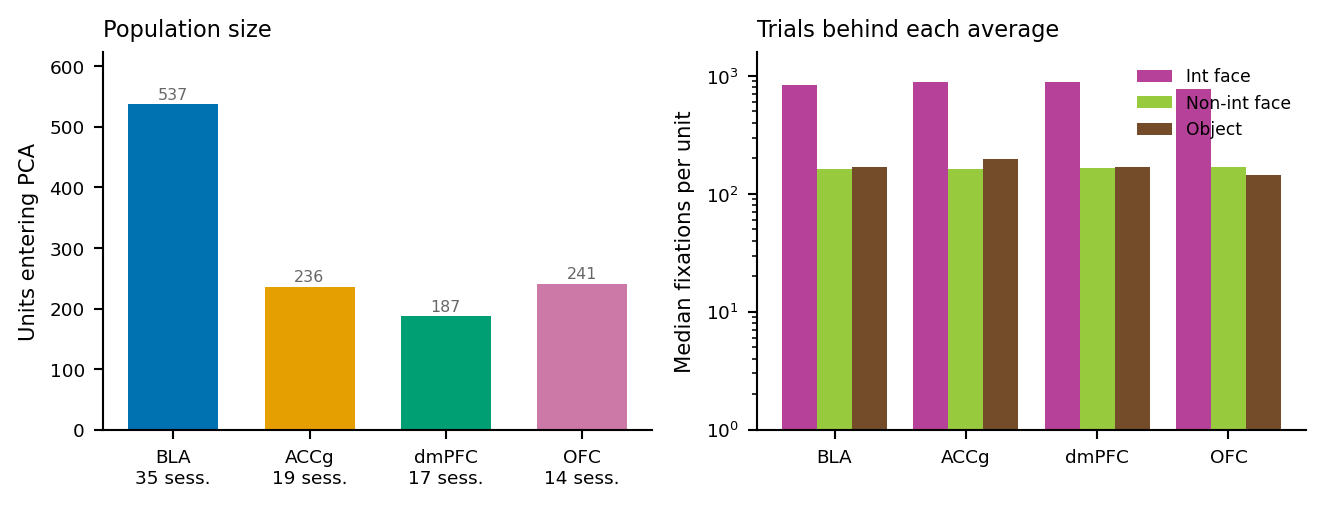

In [2]:
all_populations = pcs.load_region_populations(DATASET_CFG_PATH, window_ms=WINDOW_MS)

if UNIT_SCOPE == "pair_selective":
    selective_units, selective_pairs = pcs.load_pair_selective_units(DATASET_CFG_PATH)
    populations = pcs.load_region_populations(
        DATASET_CFG_PATH, window_ms=WINDOW_MS, unit_keys=selective_units["unit_key"]
    )
    selectivity_summary = save_table(
        pcs.summarize_selective_units(selective_units, selective_pairs, populations=all_populations),
        "selective_unit_summary",
    )
    display(Markdown("**Fixation-pair selective units retained**"))
    display(selectivity_summary)
else:
    selective_units = selective_pairs = selectivity_summary = None
    populations = all_populations

inventory = save_table(pcs.build_unit_inventory(populations), "unit_inventory")
display(inventory[[
    "region", "n_units", "n_sessions", "n_time_bins",
    "fr_matrix_units_by_time", "concatenated_matrix_units_by_time", "max_pca_rank",
]])
show(viz.plot_unit_inventory(inventory), "fig00_unit_inventory")

## 2. Notation, and exactly what the PCA does

### The matrices

For region $R$ with $N$ units, $T = 100$ time bins of 10 ms spanning
$[-500, +500]$ ms, and conditions $c \in \{\mathrm{IF}, \mathrm{NF}, \mathrm{OB}\}$:

$$X_c \in \mathbb{R}^{N \times T}, \qquad
[X_c]_{n t} = \text{mean firing rate of unit } n \text{ at bin } t \text{ for condition } c$$

The concatenation is along **time**, in a fixed condition order:

$$X = \begin{bmatrix} X_{\mathrm{IF}} & X_{\mathrm{NF}} & X_{\mathrm{OB}}\end{bmatrix}
\in \mathbb{R}^{N \times 3T}$$

### The PCA

Time bins are **samples**, units are **features**. Let $Y = X^{\top} \in \mathbb{R}^{3T \times N}$,

$$\mu = \frac{1}{3T}\sum_{s=1}^{3T} Y_{s\cdot} \in \mathbb{R}^{N},
\qquad \tilde{Y} = Y - \mathbf{1}\mu^{\top},
\qquad \tilde{Y} = U \Sigma V^{\top}$$

The **components** are the leading right singular vectors, $W = V_{:,1:k}^{\top} \in \mathbb{R}^{k \times N}$,
with $W W^{\top} = I_k$. Each row is a direction in neuron space — a weighting
over the $N$ neurons.

The **scores** (trajectories) are

$$Z_c = W\left(X_c - \mu \mathbf{1}^{\top}\right) \in \mathbb{R}^{k \times T}$$

so $Z_c(t) \in \mathbb{R}^{k}$ is the population state at bin $t$, and the
back-projection is $\hat{X}_c = W^{\top} Z_c + \mu\mathbf{1}^{\top}$.

Variance explained by component $j$:
$\lambda_j = \sigma_j^2 / (3T - 1)$, ratio $\lambda_j / \sum_i \lambda_i$.

### Two centrings, and why the distinction runs through everything below

There are two different means in play, and nearly every interpretive question in
this notebook turns on which one was used.

| Fit | Centred on | Consequence |
| --- | --- | --- |
| **Concatenated** ($W$, $\mu$ above) | the grand mean over all $3T$ samples | Each condition keeps its own offset from that grand mean. This is why the 3D trajectories appear as three separated clouds. |
| **Per condition** ($W_c$, $\mu_c = \frac{1}{T}\sum_t X_c(:,t)$) | that condition's **own centroid** | The offset is removed before the basis is computed. $W_c$ describes only how condition $c$ *varies about its own mean*. |

Everything positional — centroid distances, the 3D pictures — uses the
concatenated fit. Everything in §7 that compares *subspaces* uses per-condition
fits, and is therefore already blind to the offsets. §7d checks that numerically
rather than asserting it.

### The concatenation contract

Column block $i$ of $Z$ must map back to condition $i$, in the same order in and
out. This is the step most likely to fail silently — a block swap would relabel
every trajectory while leaving every figure looking plausible — so §3 asserts it
as a numerical identity.

In [3]:
for region, population in populations.items():
    concatenated = population.concatenated_units_by_time()
    print(f"{region:>6}  N={population.n_units:4d} units, T={population.n_time} bins")
    print(f"        X_c  (units x time)          = {population.condition_matrix(population.conditions[0]).shape}")
    print(f"        X    (units x 3T)            = {concatenated.shape}")
    print(f"        column blocks                = {population.condition_slices()}")
    print(f"        max PCA rank min(N, 3T-1)    = {min(population.n_units, 3 * population.n_time - 1)}")

   bla  N= 537 units, T=100 bins
        X_c  (units x time)          = (537, 100)
        X    (units x 3T)            = (537, 300)
        column blocks                = {'face_interactive': (0, 100), 'face_non_interactive': (100, 200), 'object': (200, 300)}
        max PCA rank min(N, 3T-1)    = 299
  accg  N= 236 units, T=100 bins
        X_c  (units x time)          = (236, 100)
        X    (units x 3T)            = (236, 300)
        column blocks                = {'face_interactive': (0, 100), 'face_non_interactive': (100, 200), 'object': (200, 300)}
        max PCA rank min(N, 3T-1)    = 236
 dmpfc  N= 187 units, T=100 bins
        X_c  (units x time)          = (187, 100)
        X    (units x 3T)            = (187, 300)
        column blocks                = {'face_interactive': (0, 100), 'face_non_interactive': (100, 200), 'object': (200, 300)}
        max PCA rank min(N, 3T-1)    = 187
   ofc  N= 241 units, T=100 bins
        X_c  (units x time)          = (241, 100)
     

## 3. Verification

### 3a. Numerical identities

Seven checks per region. Six are exact linear-algebra facts; the seventh guards
against a one-bin time shift when the concatenated projection is sliced apart.

| Check | Identity | A failure would mean |
| --- | --- | --- |
| `components_orthonormal` | $WW^{\top} = I_k$ | the basis is not orthonormal, so projections double-count variance |
| `fit_mean_is_sample_mean` | $\mu = \frac{1}{3T}\sum_s Y_{s\cdot}$ | conditions centred on the wrong mean, shifting every trajectory |
| `concatenation_slice_roundtrip` | $Z[:, (i-1)T{:}\,iT] = W(X_{c_i} - \mu\mathbf{1}^{\top})$ | **the slice step returns the wrong block — trajectories mislabelled** |
| `concatenated_scores_match_manual_projection` | stored $Z$ equals $W(X-\mu\mathbf{1}^\top)$ | stored scores stale relative to the stored basis |
| `full_rank_reconstruction_exact` | $W^{\top}WX_c^{\text{ctr}} = X_c^{\text{ctr}}$ at full rank | back-projection does not invert the projection |
| `projection_preserves_total_energy` | $\|W\tilde{X}\|_F^2 = \|\tilde{X}\|_F^2$ (Parseval) | variance lost or created in the projection |
| `time_order_not_shifted` | zero-lag alignment beats a one-bin roll | a condition block written back off-by-one in time |

**28 / 28 identity checks pass**

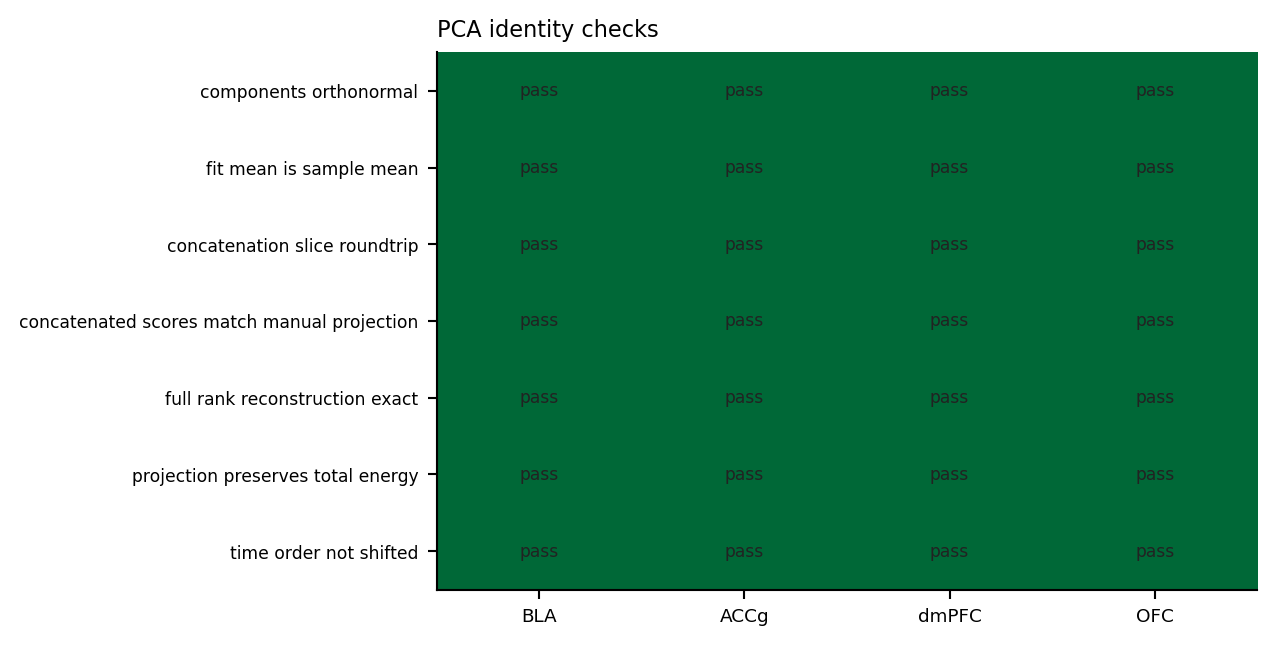

,check,criterion,value,tolerance
0,components_orthonormal,|value| <= tolerance,2.664535e-15,1.000000e-09
1,fit_mean_is_sample_mean,|value| <= tolerance,0.000000e+00,1.000000e-08
2,concatenation_slice_roundtrip,|value| <= tolerance,0.000000e+00,1.000000e-08
3,concatenated_scores_match_manual_projection,|value| <= tolerance,8.881784e-15,1.000000e-08
4,full_rank_reconstruction_exact,|value| <= tolerance,3.552714e-14,1.000000e-08
5,projection_preserves_total_energy,|value| <= tolerance,2.931446e-18,1.000000e-09
6,time_order_not_shifted,value > tolerance,7.350940e+02,0.000000e+00


In [4]:
fits = {region: pcs.fit_all_scopes(population) for region, population in populations.items()}

checks = save_table(
    pd.concat(
        [
            pcs.verify_pca_identities(population, fits[region]["concatenated"])
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "pca_identity_checks",
)
n_failed = int((~checks["passed"]).sum())
display(Markdown(
    f"**{len(checks) - n_failed} / {len(checks)} identity checks pass**"
    + ("" if n_failed == 0 else f" — **{n_failed} FAILED**")
))
show(viz.plot_verification_summary(checks), "fig01_identity_checks")
display(checks.loc[~checks["passed"]] if n_failed else checks.head(7)[["check", "criterion", "value", "tolerance"]])

### 3b. Does the interactive-face trajectory actually belong to interactive face?

The identities above prove the arithmetic is self-consistent. They do **not**
prove the labels are right: a pipeline that swapped two conditions consistently
would pass every one of them.

This check goes the other way round. Reconstruct each condition from its own
truncated scores, $\hat{X}_a = W^{\top}Z_a + \mu\mathbf{1}^{\top}$, then score
that reconstruction against **every** condition's true rates:

$$R^2(a \to b) = 1 - \frac{\|X_b - \hat{X}_a\|_F^2}{\|X_b - \bar{X}_b\|_F^2}$$

If the labelling is correct the winning match must lie on the diagonal for all
three conditions.

**Reading the numbers.** The diagonal is the fraction of a condition's own
temporal variance that the shared $k$-dimensional subspace captures — a real
quantity, not a formality. The off-diagonal entries are large and *negative*,
which is expected rather than a bug: reconstructing one condition and scoring it
against another does worse than predicting that other condition's own mean, so
$R^2 < 0$. The more negative, the more distinct the two conditions are.

In [5]:
dimensionality = save_table(pcs.build_dimensionality_table(fits), "dimensionality_by_region")
SHARED_N_COMPONENTS, per_region_components = pcs.resolve_shared_n_components(
    fits, threshold=VARIANCE_THRESHOLD
)

confusion = save_table(
    pd.concat(
        [
            pcs.condition_identity_confusion(
                population, fits[region]["concatenated"], n_components=SHARED_N_COMPONENTS
            )
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "condition_identity_confusion",
)
diagonal = confusion[confusion["reconstructed_from"] == confusion["compared_against"]]
display(Markdown(
    f"**Condition identity recovered in {int(diagonal['identity_recovered'].sum())} / {len(diagonal)} "
    f"region x condition cases** (reconstruction at k = {SHARED_N_COMPONENTS})."
))
for region in confusion["region"].unique():
    display(Markdown(f"`{region}` — R² of reconstruction (rows) against true rates (columns)"))
    display(
        confusion[confusion["region"] == region]
        .pivot(index="reconstructed_from", columns="compared_against", values="r2")
        .round(3)
    )

**Condition identity recovered in 12 / 12 region x condition cases** (reconstruction at k = 42).

`bla` — R² of reconstruction (rows) against true rates (columns)

compared_against,face_interactive,face_non_interactive,object
reconstructed_from,,,
face_interactive,0.751,-1.480,-2.361
face_non_interactive,-6.559,0.939,-3.261
object,-8.507,-2.962,0.932


`accg` — R² of reconstruction (rows) against true rates (columns)

compared_against,face_interactive,face_non_interactive,object
reconstructed_from,,,
face_interactive,0.750,-1.316,-2.347
face_non_interactive,-8.010,0.947,-3.799
object,-10.411,-3.210,0.938


`dmpfc` — R² of reconstruction (rows) against true rates (columns)

compared_against,face_interactive,face_non_interactive,object
reconstructed_from,,,
face_interactive,0.788,-2.537,-2.077
face_non_interactive,-15.320,0.962,-4.706
object,-10.885,-3.773,0.954


`ofc` — R² of reconstruction (rows) against true rates (columns)

compared_against,face_interactive,face_non_interactive,object
reconstructed_from,,,
face_interactive,0.811,-1.733,-2.433
face_non_interactive,-6.928,0.943,-2.431
object,-11.641,-3.360,0.956


### 3c. This analysis against the stored `results.pkl`

Quantifies the provenance gap from §1. `unit_sets_identical` should be true — the
two pipelines select the same neurons. The dimensionality columns are where they
part company, and `stored_max_components` shows a second issue: the stored run
caps PCA at 50 components (`population_pca_max_components: 50`), so for regions
needing more than that the stored cumulative curve never reaches 95% and the
retained-dimension question cannot be answered from it at all.

In [6]:
stored_comparison = pcs.verify_against_stored_pca(populations, fits, cfg_path=DATASET_CFG_PATH)
if len(stored_comparison):
    display(save_table(stored_comparison, "stored_pca_comparison"))
else:
    display(Markdown("_No stored `results.pkl` found; skipping._"))

,region,n_units_stored,n_units_current,n_units_shared,unit_sets_identical,stored_max_components,stored_cumulative_at_cap,stored_n_pcs_for_95pct,current_n_pcs_for_95pct,stored_evr_pc1,current_evr_pc1
0,accg,236,236,236,True,50,0.971613,42,40,0.264855,0.320573
1,bla,537,537,537,True,50,0.964411,45,42,0.255672,0.282860
2,dmpfc,187,187,187,True,50,0.983151,34,33,0.372672,0.376625
3,ofc,241,241,241,True,50,0.975395,39,38,0.283019,0.319171


## 4. How many PCs to keep

### The quantity

$$\text{cum}(k) = \frac{\sum_{j=1}^{k}\lambda_j}{\sum_{j=1}^{\min(N,\,3T-1)}\lambda_j},
\qquad k^{*}(R) = \min\{k : \text{cum}(k) \ge 0.95\}$$

The denominator runs over **all** components, so this is the ordinary fraction of
total variance. The fit here is full-rank (no configured cap), which is what makes
$k^{*}$ a measurement rather than a number clipped by a setting.

### The shared dimension

$$k = \max_{R} k^{*}(R)$$

The maximum, not the mean: it guarantees the retained subspace reaches the
threshold in **every** region, so no area is analysed in a space too small for
it. This is the same rule the mRNN target builder applies, so the two analyses
work in comparably sized spaces.

### Why $k \approx 40$ and not $\approx 20$

These counts come from the **concatenated** fit, which spans three conditions'
worth of structure. A single condition's own fit needs roughly half as many — the
per-condition rows in the table below show the difference directly. Neither
number is "the dimensionality of the region"; they answer different questions.

### Why 3 PCs are used for pictures and $k$ for everything else

Three PCs capture only around half the concatenated variance. Any subspace
comparison computed on them would be a comparison of the visualisation, not of
the populations, so every quantitative result below uses all $k$.

**k = 42 PCs reach 95% of the concatenated variance in every region.**  Per region: ACCg 40, BLA 42, dmPFC 33, OFC 38.  Binding region: BLA.

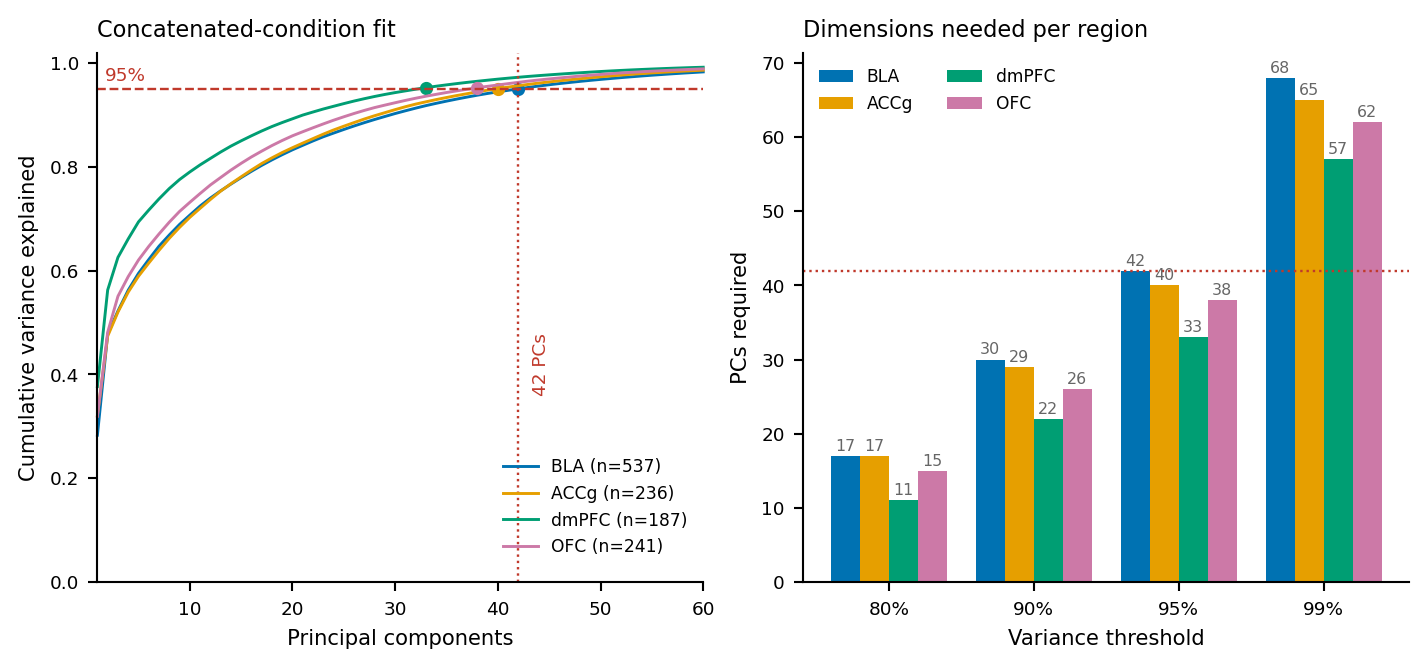

,region,fit_scope,n_units,n_components_full_rank,n_pcs_for_80pct,n_pcs_for_90pct,n_pcs_for_95pct,n_pcs_for_99pct,participation_ratio,explained_variance_ratio_pc1
0,accg,concatenated,236,236,17,29,40,65,7.350388,0.320573
1,accg,face_interactive,236,99,11,15,19,27,11.428828,0.182115
2,accg,face_non_interactive,236,99,12,16,20,28,13.884554,0.142206
3,accg,object,236,99,12,16,20,27,12.785477,0.179323
4,bla,concatenated,537,299,17,30,42,68,7.841189,0.282860
5,bla,face_interactive,537,99,9,14,18,26,6.561523,0.331265
6,bla,face_non_interactive,537,99,12,16,20,28,14.082901,0.141066
7,bla,object,537,99,12,16,20,28,12.132682,0.170329
8,dmpfc,concatenated,187,187,11,22,33,57,5.373985,0.376625
9,dmpfc,face_interactive,187,99,11,15,19,26,10.762425,0.188262


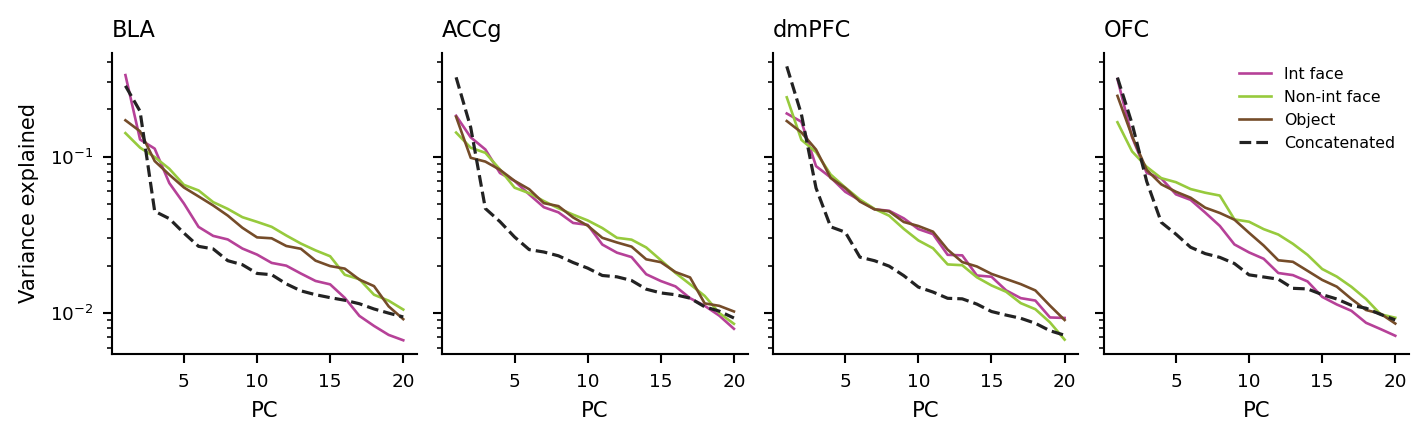

In [7]:
binding = max(per_region_components, key=per_region_components.get)
display(Markdown(
    f"**k = {SHARED_N_COMPONENTS} PCs reach {VARIANCE_THRESHOLD:.0%} of the concatenated variance "
    f"in every region.**  Per region: "
    + ", ".join(f"{style.region_label(r)} {c}" for r, c in sorted(per_region_components.items()))
    + f".  Binding region: {style.region_label(binding)}."
))
show(
    viz.plot_cumulative_variance(fits, threshold=VARIANCE_THRESHOLD, shared_n_components=SHARED_N_COMPONENTS),
    "fig02_cumulative_variance",
)
display(dimensionality[[
    "region", "fit_scope", "n_units", "n_components_full_rank",
    "n_pcs_for_80pct", "n_pcs_for_90pct", "n_pcs_for_95pct", "n_pcs_for_99pct",
    "participation_ratio", "explained_variance_ratio_pc1",
]])
show(viz.plot_variance_spectra(fits), "fig03_variance_spectra")

### Participation ratio, in the table above

$$\mathrm{PR} = \frac{\left(\sum_j \lambda_j\right)^2}{\sum_j \lambda_j^2}$$

An effective dimension count that needs no threshold. If $d$ components share the
variance equally, $\mathrm{PR} = d$; if one dominates, $\mathrm{PR} \to 1$. It is
much smaller than $k^{*}$ (single digits versus ~40) because it is dominated by
the leading components, whereas $k^{*}$ is set by the long tail. Both are correct
answers to different questions: **PR** says how many dimensions carry most of the
action, **$k^{*}$** says how many you must keep to avoid discarding 5% of it.

## 5. What the trajectories look like

All three conditions are drawn in the **concatenated** basis, so the axes mean
the same thing for every curve and the visible distances are real distances.
Drawing each condition in its own basis would give each curve its own axes and
the distances between them would mean nothing.

Viewing angles are searched per region. The conditions separate along different
PC combinations in each area, so one fixed camera cannot serve all four. The
search maximises the **product** of two normalised terms — the closest gap
between any two trajectories, and how unfolded each trajectory stays. A sum lets
a view win on separation alone, and the winner is then always a near-top-down
camera that spreads the conditions apart while collapsing every trajectory into
a scribble.

Because a camera can always be chosen to flatter the data, the fixed PC-plane
projections that follow are the honest cross-check: they have no free parameters.

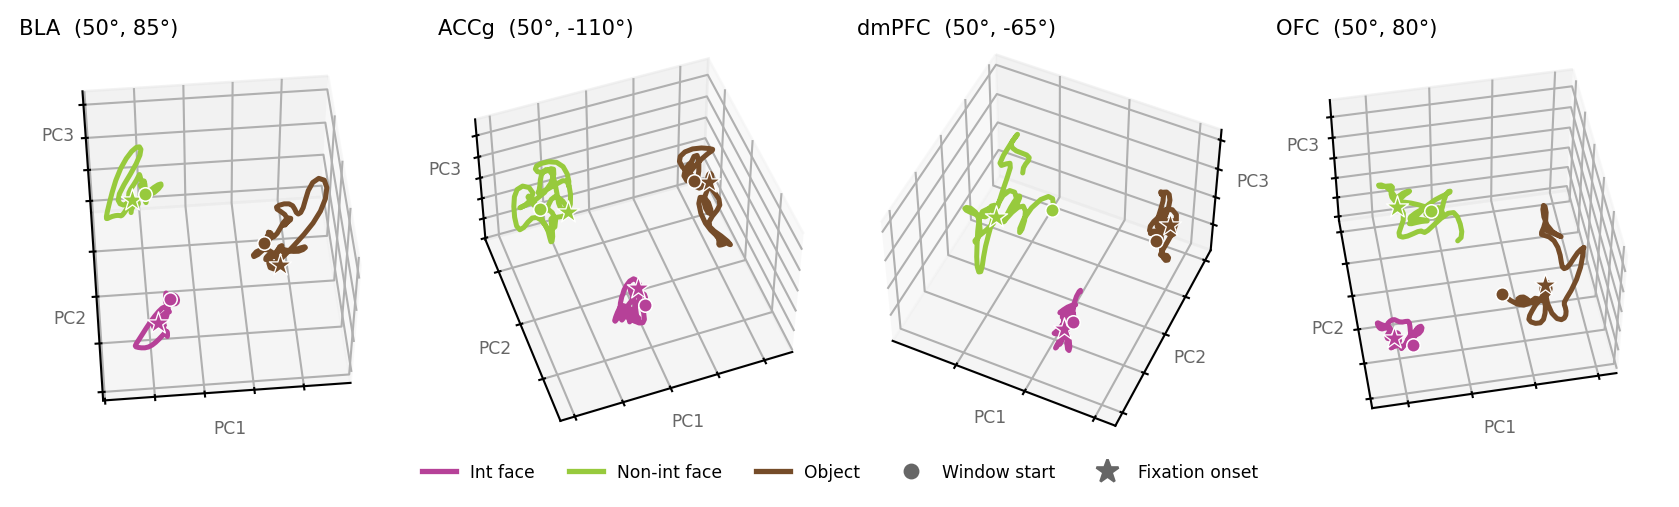

Selected views (elev°, azim°): `bla` 50, 85, `accg` 50, -110, `dmpfc` 50, -65, `ofc` 50, 80

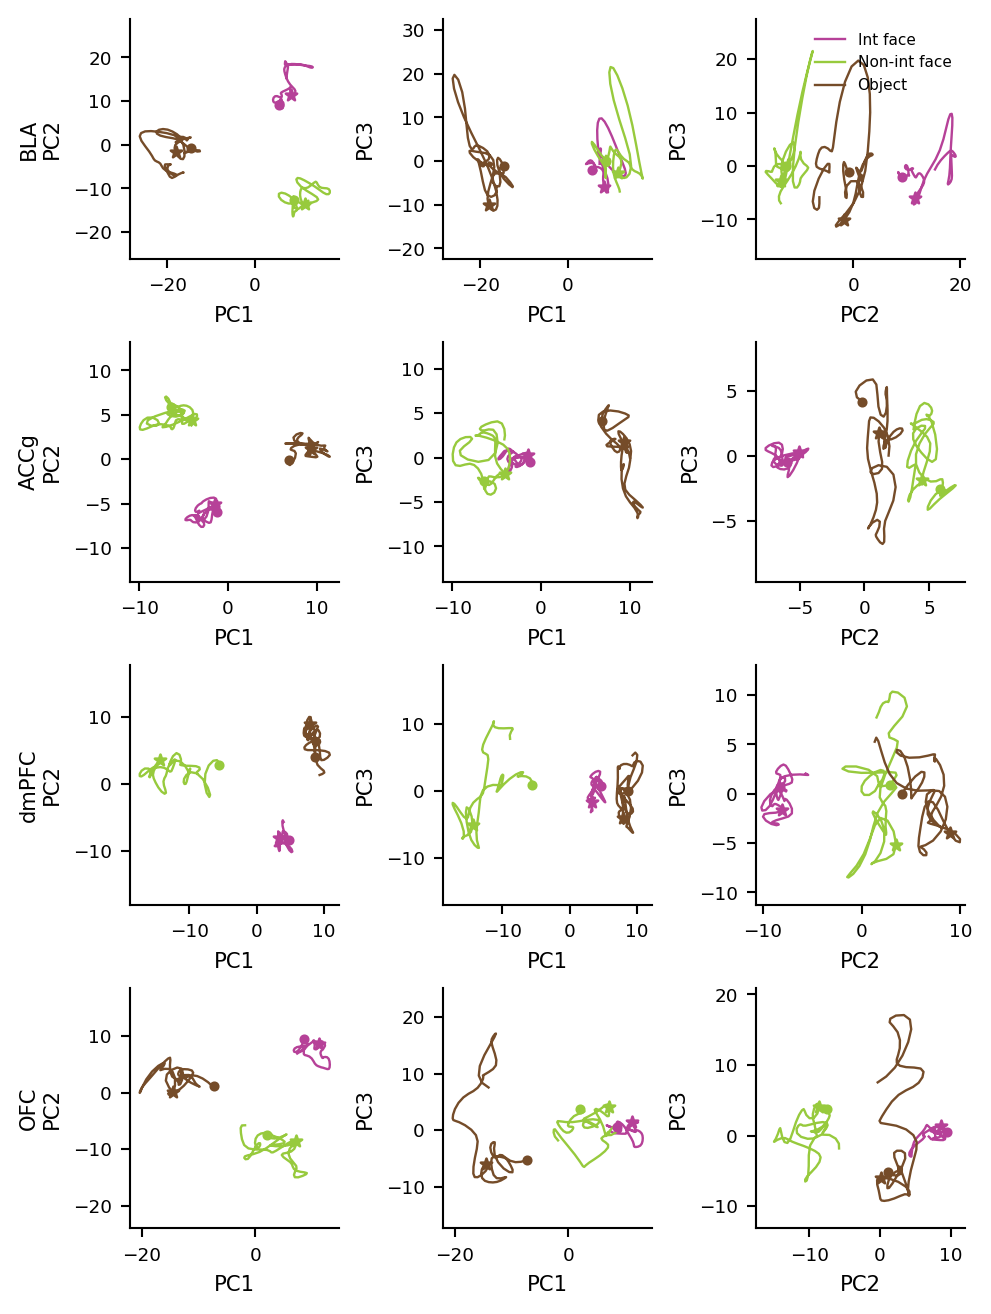

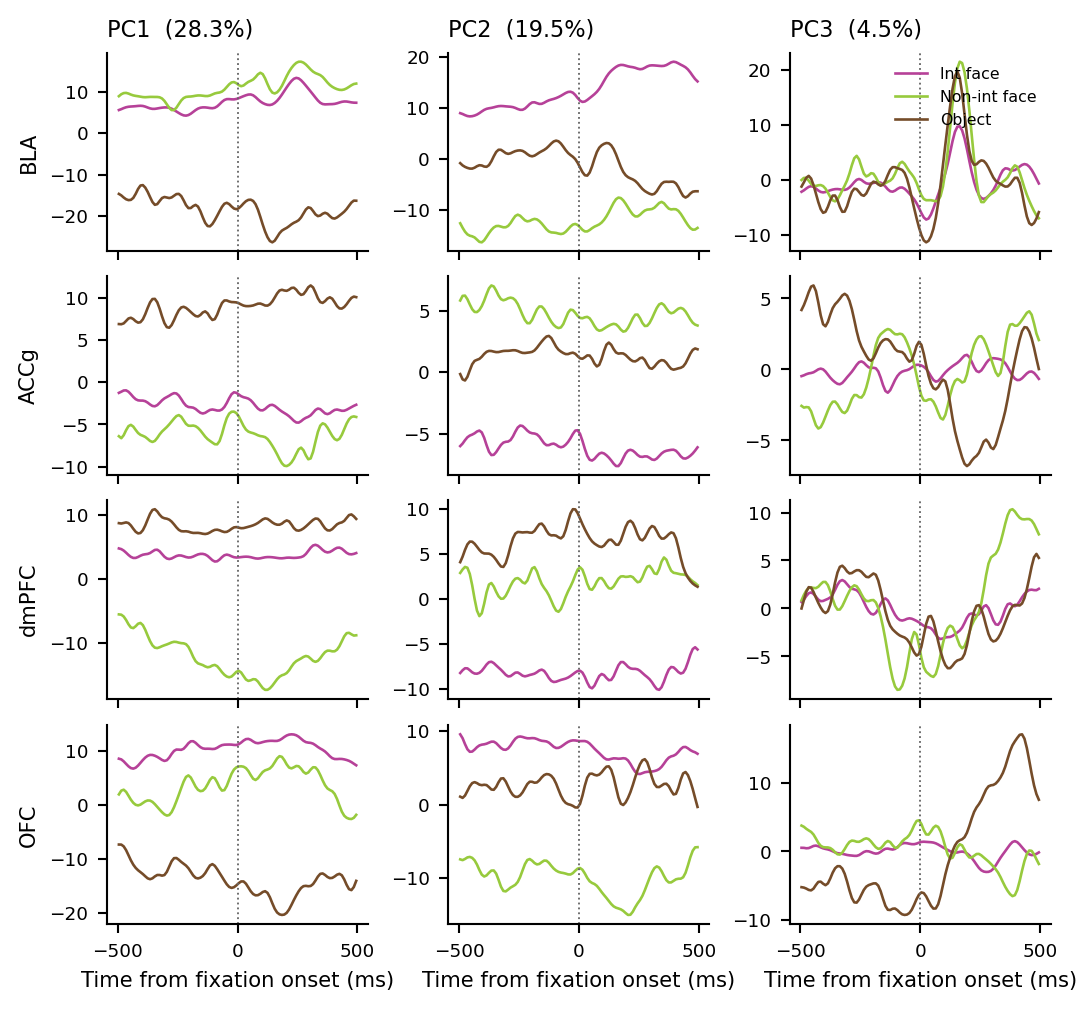

In [8]:
figure, resolved_views = viz.plot_pc_trajectories_3d(fits)
show(figure, "fig04_pc_trajectories_3d")
display(Markdown(
    "Selected views (elev°, azim°): "
    + ", ".join(f"`{r}` {a[0]:.0f}, {a[1]:.0f}" for r, a in resolved_views.items())
))
show(viz.plot_pc_plane_projections(fits), "fig05_pc_planes")
show(viz.plot_pc_timecourses(fits), "fig06_pc_timecourses")

## 6. Separating the offset from the dynamics

The PC time courses above make a structural point the 3D view hides: the leading
PCs are dominated by a near-**constant offset** between conditions. Each condition
sits in a different part of the state space and wanders comparatively little
within its own neighbourhood.

That matters, because *"the conditions occupy separated subspaces"* and *"the
conditions follow different dynamics"* are different claims and the figures so
far support only the first.

### The decomposition (two-way ANOVA on the population tensor)

Write the tensor $r_{c,t,n}$ (condition $\times$ time $\times$ unit) and let
$\bar{r}_{\cdot\cdot n}$ be the grand mean over conditions and time for unit $n$.
Define three terms:

$$
\underbrace{a_{t n} = \bar{r}_{\cdot t n} - \bar{r}_{\cdot\cdot n}}_{\text{shared time course}}
\qquad
\underbrace{b_{c n} = \bar{r}_{c \cdot n} - \bar{r}_{\cdot\cdot n}}_{\text{condition offset}}
\qquad
\underbrace{e_{c t n} = r_{c t n} - \bar{r}_{\cdot\cdot n} - a_{t n} - b_{c n}}_{\text{condition} \times \text{time interaction}}
$$

Because the design is balanced (every condition has the same $T$), the three are
**mutually orthogonal** and the sums of squares add exactly:

$$\underbrace{\sum_{c,t,n}(r_{ctn}-\bar{r}_{\cdot\cdot n})^2}_{\text{SS}_{\text{total}}}
= \underbrace{C\sum_{t,n} a_{tn}^2}_{\text{SS}_{\text{time}}}
+ \underbrace{T\sum_{c,n} b_{cn}^2}_{\text{SS}_{\text{offset}}}
+ \underbrace{\sum_{c,t,n} e_{ctn}^2}_{\text{SS}_{\text{interaction}}}$$

The reported shares are $\text{SS}_{\bullet} / \text{SS}_{\text{total}}$, so they
sum to 1 by construction (a useful check on the table below).

### What each share means

| Term | What it is | What a large value means |
| --- | --- | --- |
| **Shared time course** | the fixation-locked response every condition follows | the population responds to *fixating*, regardless of what is fixated |
| **Condition offset** | a static per-condition displacement, constant over the window | conditions differ by *where the population sits*, not by what it does over time |
| **Condition × time** | everything left: condition-specific dynamics | conditions differ in *how the response unfolds* |

### Yes — the offset removal is centroid subtraction

`marginalize_population` implements exactly the terms above:

- `remove_condition_offset` subtracts $b_{cn}$, i.e. **each condition's own
  time-average, per neuron**. In the PC space this is
  $d_c(t) = Z_c(t) - m_c$ with $m_c = \frac{1}{T}\sum_t Z_c(t)$ — the centroid.
  So: yes, it is centroid subtraction, done per condition and per neuron.
- `remove_shared_time_course` subtracts $a_{tn}$, the across-condition mean at
  each time bin.
- `condition_dynamics_only` subtracts both, leaving $e_{ctn}$ alone.

Refitting PCA on the residual is what makes the condition-specific dynamics
visible; in the raw fit they are buried under terms three to five times larger.

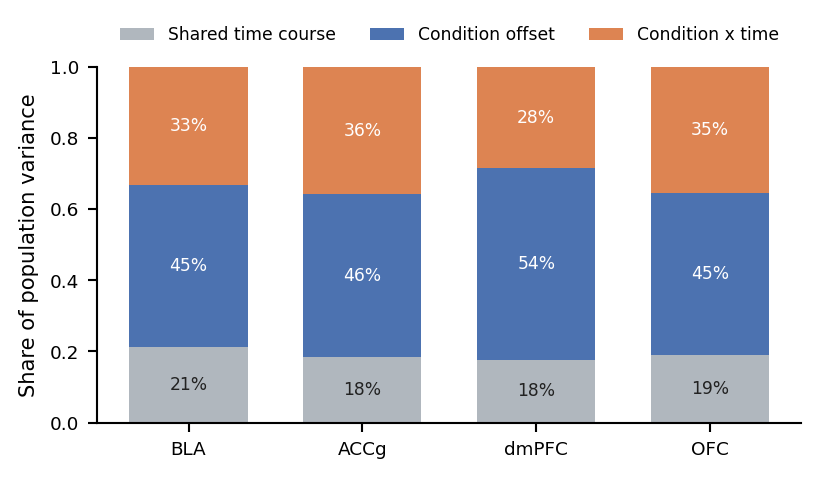

component,condition_by_time_interaction,condition_independent_time,condition_main_effect,condition_related_total
region,,,,
accg,0.357,0.184,0.458,0.816
bla,0.333,0.212,0.455,0.788
dmpfc,0.284,0.177,0.539,0.823
ofc,0.354,0.191,0.455,0.809


Orthogonality check — the three components sum to `accg` 1.0000, `bla` 1.0000, `dmpfc` 1.0000, `ofc` 1.0000 (should be 1.0000).

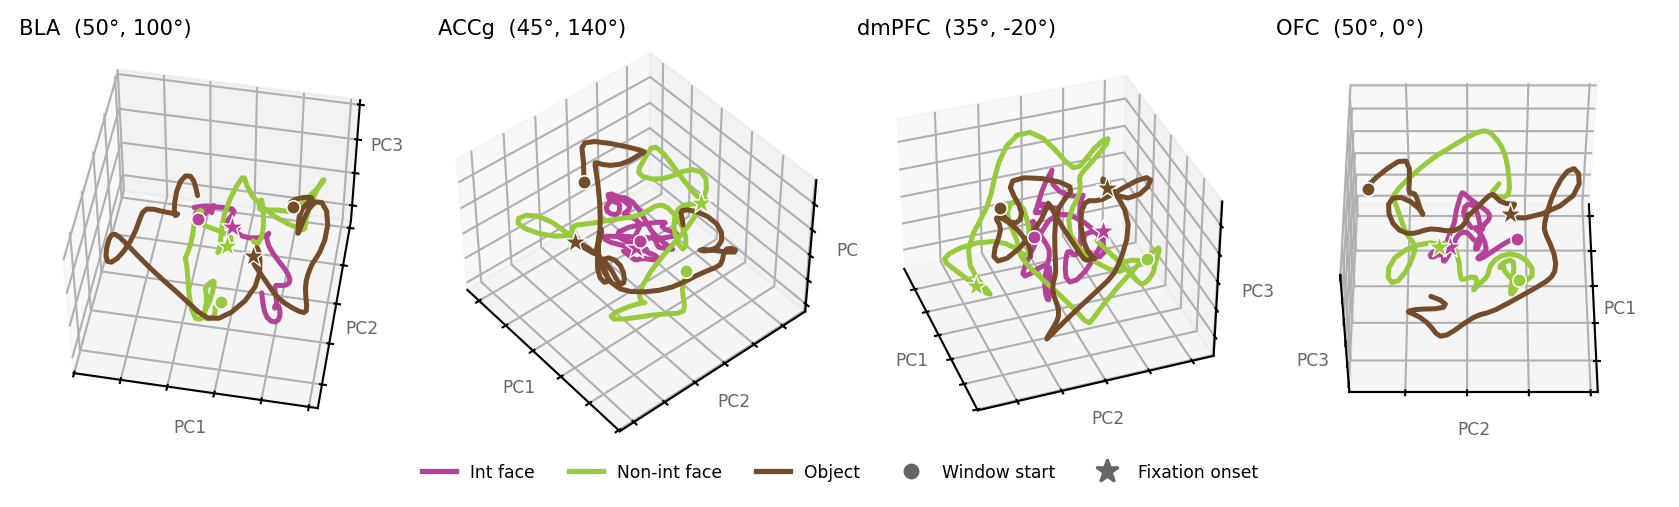

Above: the same populations after removing **both** the shared time course and each condition's offset. What remains is the interaction term alone. Compare with fig04 — the clean separation there was carried by the offsets.

In [9]:
decomposition = save_table(
    pd.concat(
        [pcs.condition_variance_decomposition(population) for population in populations.values()],
        ignore_index=True,
    ),
    "variance_decomposition",
)
show(viz.plot_variance_decomposition(decomposition), "fig07_variance_decomposition")
shares = decomposition.pivot(index="region", columns="component", values="fraction_of_total")
display(shares.round(3))
display(Markdown(
    "Orthogonality check — the three components sum to "
    + ", ".join(
        f"`{r}` {shares.loc[r, ['condition_independent_time', 'condition_main_effect', 'condition_by_time_interaction']].sum():.4f}"
        for r in shares.index
    )
    + " (should be 1.0000)."
))

dynamics_fits = {
    region: {
        "concatenated": pcs.fit_population_pca(
            pcs.marginalize_population(population, mode="condition_dynamics_only")
        )
    }
    for region, population in populations.items()
}
figure, _ = viz.plot_pc_trajectories_3d(dynamics_fits)
show(figure, "fig08_condition_dynamics_only_3d")
display(Markdown(
    "Above: the same populations after removing **both** the shared time course and each "
    "condition's offset. What remains is the interaction term alone. Compare with fig04 — "
    "the clean separation there was carried by the offsets."
))

## 7. Comparing the condition subspaces

Everything in this section uses **per-condition** fits, which centre on each
condition's own mean. They are therefore measures of *covariance structure*, not
of position — §7d verifies that.

### 7a. Cross-condition variance explained

Let $\tilde{X}_c = X_c - \mu_c\mathbf{1}^{\top}$ (condition $c$ about its own
centroid) and

$$C_c = \frac{1}{T-1}\tilde{X}_c\tilde{X}_c^{\top} \in \mathbb{R}^{N \times N}$$

its temporal covariance across neurons. Let $V_a \in \mathbb{R}^{N \times k}$ hold
the top-$k$ eigenvectors of $C_a$. Then

$$\text{captured}(a \to b) = \operatorname{tr}\!\left(V_a^{\top} C_b V_a\right),
\qquad
\text{fraction}(a \to b) = \frac{\operatorname{tr}(V_a^{\top} C_b V_a)}{\operatorname{tr}(C_b)}$$

In words: **take condition $a$'s principal directions, project condition $b$'s
activity onto them, and ask what fraction of $b$'s variance survives.**

It is **asymmetric**: $\text{fraction}(a\to b) \ne \text{fraction}(b\to a)$,
because a condition with broadly spread variance makes a more general basis. That
asymmetry is informative and is not averaged away in the tables.

### 7b. Alignment index — and why the raw fraction is not enough

The fraction above has no natural scale: how much *could* any $k$-dimensional
subspace capture of $C_b$? At most the top-$k$ eigenvalues. Normalising by that
ceiling gives the alignment index (Elsayed et al., 2016):

$$A(a \to b) = \frac{\operatorname{tr}\left(V_a^{\top} C_b V_a\right)}{\sum_{j=1}^{k}\lambda_j(C_b)} \in [0, 1]$$

- $A = 1$: $a$'s directions are **as good for $b$** as $b$'s own optimal
  $k$-dimensional subspace. The two conditions vary in the same subspace.
- $A = 0$: $a$'s directions carry none of $b$'s variance — orthogonal subspaces.

The normalisation is what makes values comparable across conditions: a low raw
fraction could just mean $b$ is low-variance, whereas a low $A$ means genuinely
different directions.

#### The floor is $k/N$, and it is not the same in every region

A **uniformly random** $k$-dimensional subspace of $\mathbb{R}^{N}$ captures, in
expectation, a fraction $k/N$ of the trace of *any* covariance. So

$$\mathbb{E}\left[A_{\text{random}}\right] \approx \frac{k}{N}$$

This is checked against simulation below (they agree to three decimals). It has a
sharp consequence: **raw alignment indices must not be compared across regions.**
At $k = 42$ the floor is $42/537 = 0.08$ in BLA but $42/187 = 0.22$ in dmPFC, so
dmPFC's higher alignment values are partly just its smaller population. The
comparable quantity rescales chance to zero:

$$A^{\dagger} = \frac{A - k/N}{1 - k/N}$$

**Read `alignment_above_floor` for anything cross-region.**

#### The ceiling

$A = 1$ is unreachable in practice because a subspace estimated from finite noisy
data does not perfectly capture even its own condition. The within-condition
ceiling (fit on odd time bins, evaluate on even) bounds how high $A$ could
plausibly go. Because the traces are smoothed at $\sigma = 2$ bins, odd and even
bins are not independent and this ceiling is **optimistic** — it is an upper
bound on plausible alignment, not a noise estimate.

### 7c. Principal angles

The scale-free counterpart. For orthonormal bases $V_a, V_b \in \mathbb{R}^{N\times k}$,
the principal angles $0 \le \theta_1 \le \cdots \le \theta_k \le 90°$ satisfy

$$\cos\theta_j = s_j\!\left(V_a^{\top} V_b\right)$$

the singular values of the $k\times k$ overlap matrix. Reading them:

| Quantity | Meaning |
| --- | --- |
| $\theta_1 = 0$ | at least one direction is shared exactly |
| $\theta_j = 90°$ | direction $j$ of $a$ is orthogonal to **all** of $b$ |
| $\sum_j \cos^2\theta_j = \|V_a^{\top}V_b\|_F^2$ | the effective **number of shared dimensions** (a real-valued count out of $k$) |
| $\overline{\cos^2\theta} = \frac{1}{k}\sum_j\cos^2\theta_j$ | shared fraction of the subspace |
| $d_{\text{Grassmann}} = \sqrt{\sum_j \theta_j^2}$ | a proper metric on subspaces |
| $d_{\text{chordal}} = \sqrt{\sum_j \sin^2\theta_j}$ | equals $\sqrt{k - \|V_a^\top V_b\|_F^2}$: the "unshared" dimension count |

Angles differ from the alignment index in one important way: they weight every
direction equally, while $A$ weights by how much variance actually lies along
each. Two conditions can share their high-variance directions (high $A$) while
their low-variance directions are unrelated (large mean angle). **Angles answer
"are the directions the same?"; $A$ answers "do the directions that matter carry
the other condition's activity?"**

The same $k/N$ caveat applies: random $k$-subspaces in a small $N$ are closer
together, so mean angles are not comparable across regions either — compare
against each region's own null.

### 7d. These measures never saw the offsets

A per-condition PCA centres on that condition's own time-average, so $V_c$
already describes deviations from the centroid, and $C_c$ is built the same way.
The alignment index and the principal angles are therefore **already** pure
dynamics measures and cannot be inflated by the conditions sitting in different
places.

That is easy to assume and easy to get wrong, so it is checked: every metric is
recomputed after explicitly subtracting each condition's centroid, and the
difference must be zero to numerical precision.

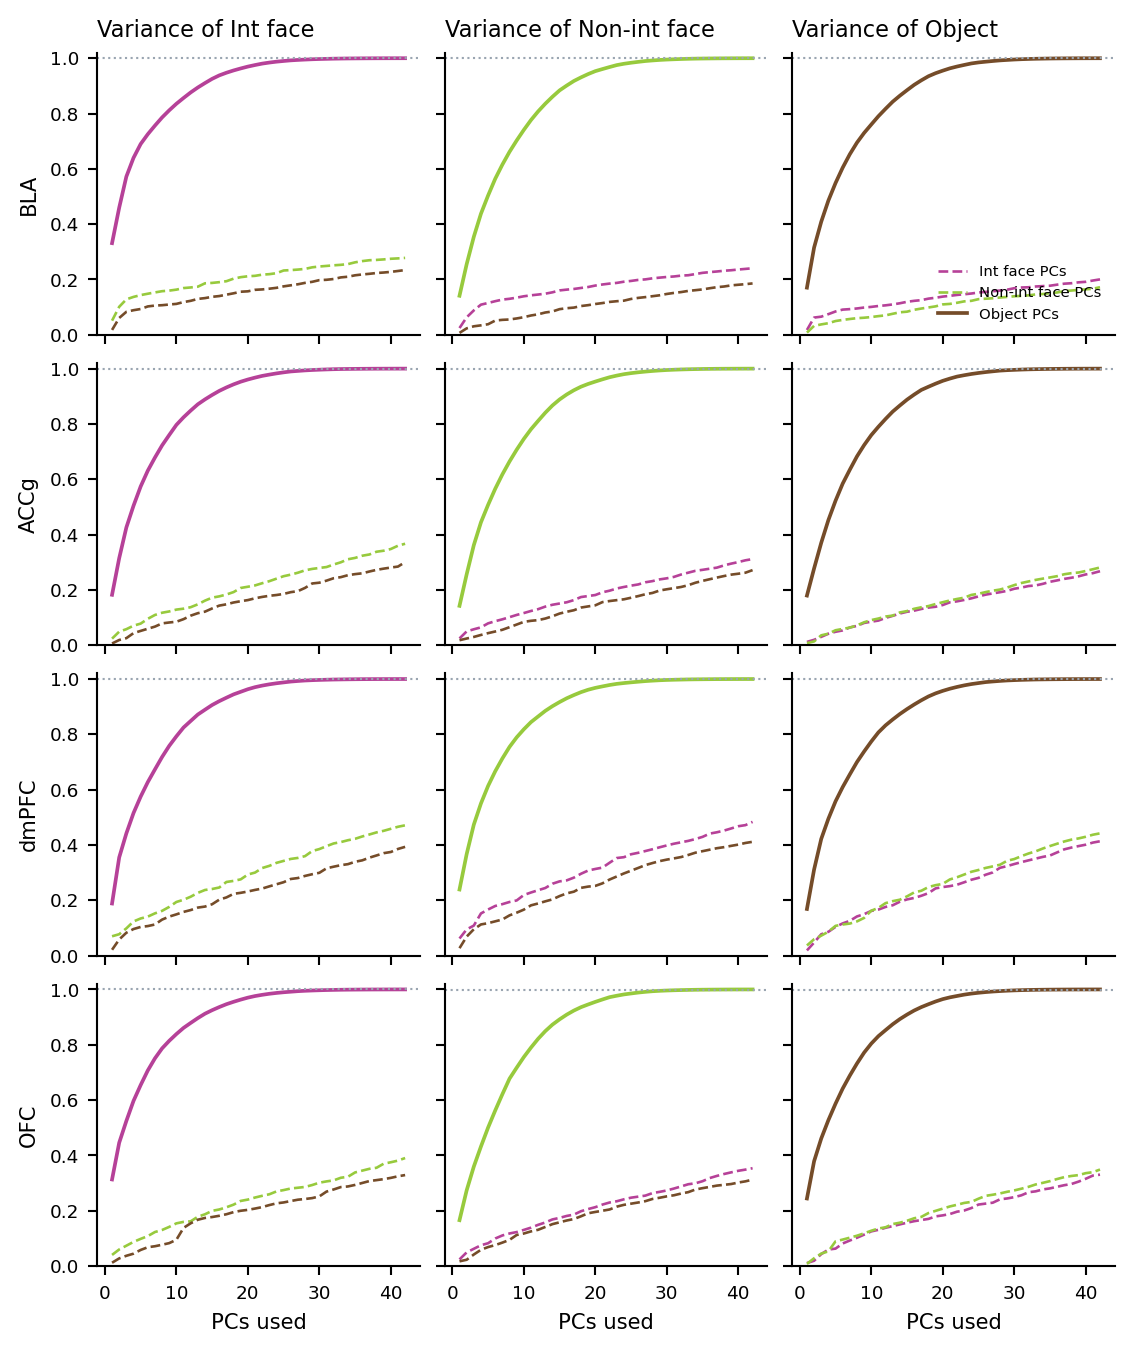

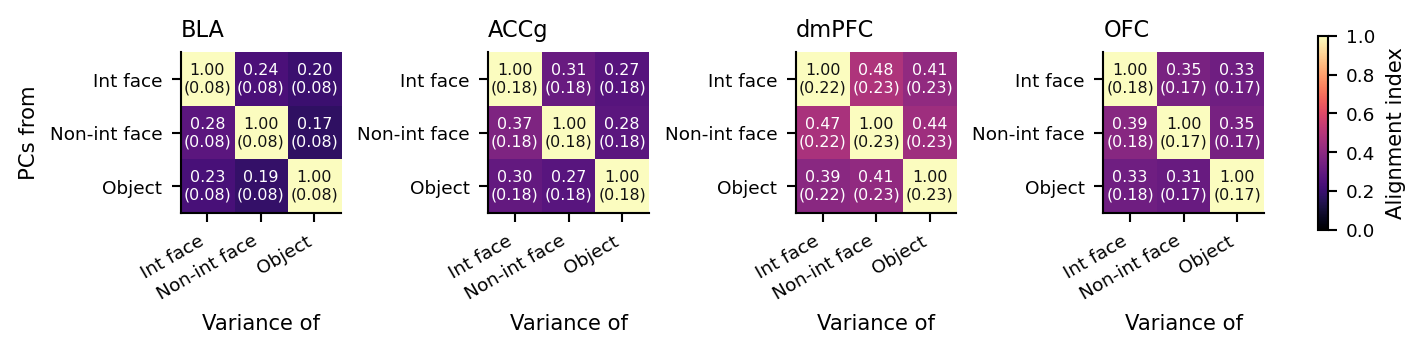

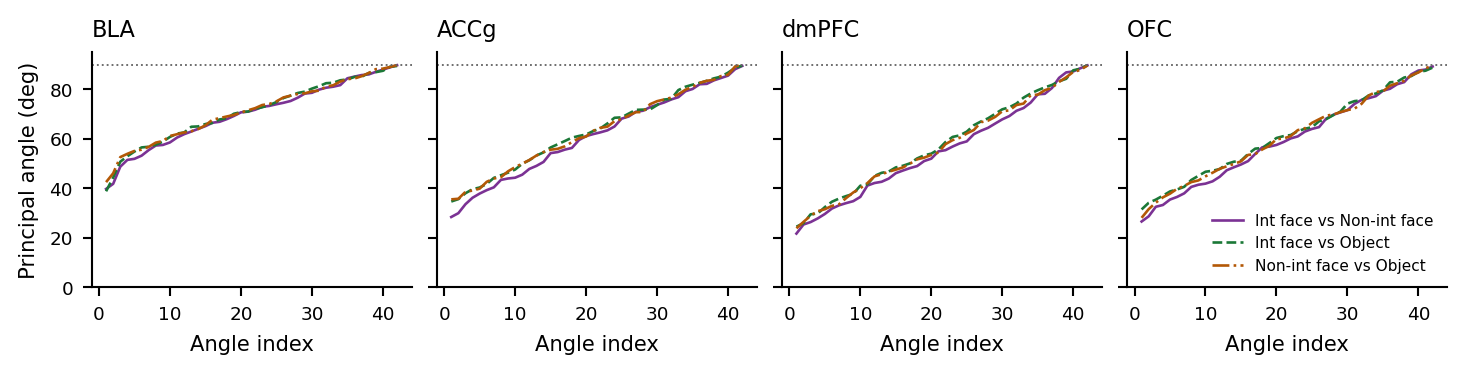

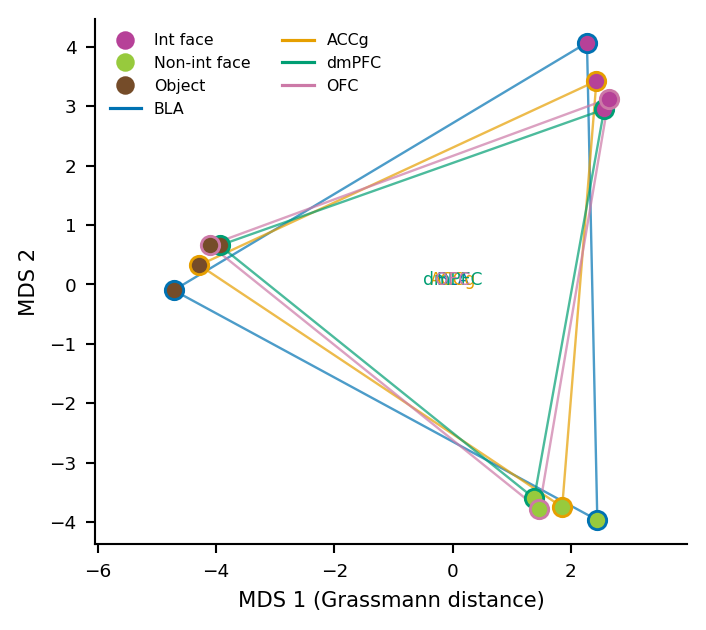

**Simulated vs analytic random-subspace floor** (should agree)

,n_units,alignment_null_mean,alignment_floor_analytic
region,,,
accg,236.0,0.1780,0.1780
bla,537.0,0.0783,0.0782
dmpfc,187.0,0.2253,0.2246
ofc,241.0,0.1749,0.1743


**Cross-condition subspace metrics** (ordered pairs)

,region,pc_condition,eval_condition,variance_explained_fraction,alignment_index,alignment_floor_analytic,alignment_above_floor,angle_mean_principal_angle,angle_mean_cos2,angle_chordal_distance
1,bla,face_interactive,face_non_interactive,0.240,0.241,0.078,0.176,69.858,0.154,5.959
2,bla,face_interactive,object,0.200,0.200,0.078,0.132,70.819,0.143,6.001
3,bla,face_non_interactive,face_interactive,0.278,0.278,0.078,0.217,69.858,0.154,5.959
5,bla,face_non_interactive,object,0.172,0.172,0.078,0.102,70.940,0.140,6.010
6,bla,object,face_interactive,0.234,0.234,0.078,0.169,70.819,0.143,6.001
7,bla,object,face_non_interactive,0.186,0.186,0.078,0.117,70.940,0.140,6.010
10,accg,face_interactive,face_non_interactive,0.311,0.311,0.178,0.162,61.207,0.276,5.514
11,accg,face_interactive,object,0.267,0.267,0.178,0.109,63.384,0.244,5.633
12,accg,face_non_interactive,face_interactive,0.367,0.367,0.178,0.230,61.207,0.276,5.514
14,accg,face_non_interactive,object,0.281,0.281,0.178,0.125,63.103,0.248,5.620


**Offset-invariance check:** alignment and principal angles are unchanged by explicit centroid removal in 12 / 12 region x pair cases (max difference 5.55e-16 in alignment, 1.42e-13° in angle).

In [10]:
subspace_table = save_table(
    pcs.build_region_subspace_summary(
        populations, fits,
        n_components=SHARED_N_COMPONENTS,
        n_null_subspaces=N_NULL_SUBSPACES,
        seed=RANDOM_SEED,
    ),
    "pairwise_subspace_metrics",
)
variance_curves = save_table(
    pd.concat(
        [
            pcs.cross_condition_variance_curve(population, fits[region], max_components=SHARED_N_COMPONENTS)
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "cross_condition_variance_curves",
)
alignment_ceiling = save_table(
    pd.concat(
        [
            pcs.within_condition_alignment_ceiling(population, n_components=SHARED_N_COMPONENTS)
            for population in populations.values()
        ],
        ignore_index=True,
    ),
    "within_condition_alignment_ceiling",
)
offset_invariance = save_table(
    pcs.verify_subspace_offset_invariance(populations, n_components=SHARED_N_COMPONENTS),
    "subspace_offset_invariance",
)

show(viz.plot_cross_condition_variance_curves(variance_curves, ceiling=alignment_ceiling), "fig09_cross_condition_variance_curves")
show(viz.plot_alignment_matrix(subspace_table), "fig10_alignment_matrix")
show(viz.plot_principal_angle_spectra(fits, n_components=SHARED_N_COMPONENTS), "fig11_principal_angle_spectra")
show(viz.plot_subspace_distance_map(fits, n_components=SHARED_N_COMPONENTS), "fig12_subspace_distance_map")

off = subspace_table.loc[~subspace_table["is_within_condition"]]
display(Markdown("**Simulated vs analytic random-subspace floor** (should agree)"))
display(
    off.groupby("region")[["n_units", "alignment_null_mean", "alignment_floor_analytic"]]
    .mean().round(4)
)
display(Markdown("**Cross-condition subspace metrics** (ordered pairs)"))
display(off[[
    "region", "pc_condition", "eval_condition",
    "variance_explained_fraction", "alignment_index", "alignment_floor_analytic",
    "alignment_above_floor", "angle_mean_principal_angle", "angle_mean_cos2",
    "angle_chordal_distance",
]].round(3))
display(Markdown(
    f"**Offset-invariance check:** alignment and principal angles are unchanged by explicit "
    f"centroid removal in {int(offset_invariance['offset_invariant'].sum())} / {len(offset_invariance)} "
    f"region x pair cases (max difference "
    f"{offset_invariance['alignment_difference'].max():.2e} in alignment, "
    f"{offset_invariance['angle_difference_deg'].max():.2e}° in angle)."
))

### 7e. Collapsed to unordered pairs

The ordered table above is the primary record. This is the same data averaged
over direction, which is what to quote when the asymmetry is not the point.
`alignment_above_floor` is the cross-region-comparable column; the effective
shared dimension count is $\|V_a^\top V_b\|_F^2 = k\,\overline{\cos^2\theta}$.

In [11]:
pair_summary = unordered_pair(off).groupby(["region", "pair_label"]).agg(
    alignment_index=("alignment_index", "mean"),
    alignment_floor=("alignment_floor_analytic", "mean"),
    alignment_above_floor=("alignment_above_floor", "mean"),
    mean_principal_angle=("angle_mean_principal_angle", "mean"),
    mean_cos2=("angle_mean_cos2", "mean"),
    chordal_distance=("angle_chordal_distance", "mean"),
).reset_index()
pair_summary["shared_dimensions"] = pair_summary["mean_cos2"] * SHARED_N_COMPONENTS
pair_summary["pair"] = pair_summary["pair_label"].map(PAIR_SHORT)
display(save_table(pair_summary, "pairwise_subspace_summary").round(3))

,region,pair_label,alignment_index,alignment_floor,alignment_above_floor,mean_principal_angle,mean_cos2,chordal_distance,shared_dimensions,pair
0,accg,face_interactive__vs__face_non_interactive,0.339,0.178,0.196,61.207,0.276,5.514,11.596,IF/NF
1,accg,face_interactive__vs__object,0.284,0.178,0.129,63.384,0.244,5.633,10.266,IF/OB
2,accg,face_non_interactive__vs__object,0.276,0.178,0.119,63.103,0.248,5.620,10.413,NF/OB
3,bla,face_interactive__vs__face_non_interactive,0.259,0.078,0.196,69.858,0.154,5.959,6.488,IF/NF
4,bla,face_interactive__vs__object,0.217,0.078,0.151,70.819,0.143,6.001,5.994,IF/OB
5,bla,face_non_interactive__vs__object,0.179,0.078,0.109,70.940,0.140,6.010,5.878,NF/OB
6,dmpfc,face_interactive__vs__face_non_interactive,0.477,0.225,0.326,55.497,0.362,5.178,15.188,IF/NF
7,dmpfc,face_interactive__vs__object,0.403,0.225,0.230,57.904,0.327,5.317,13.730,IF/OB
8,dmpfc,face_non_interactive__vs__object,0.427,0.225,0.261,57.189,0.336,5.282,14.102,NF/OB
9,ofc,face_interactive__vs__face_non_interactive,0.372,0.174,0.239,59.328,0.304,5.405,12.782,IF/NF


### 7f. A note on the stored `explained_variance_fraction` column

The existing `fixation_population_pca` builder writes a column named
`explained_variance_fraction` whose own metadata field calls it
`projection_variance_fraction_within_retained_pcs`. It normalises by

$$\frac{\sum_{j\le k} v_j^{\top}C_b v_j}{\sum_{j \le k} v_j^{\top} C_b v_j} \to 1$$

— that is, by the variance *inside* the retained PCs rather than by $b$'s total
variance. It therefore approaches 1.0 for every condition pairing once enough PCs
are retained, regardless of how different the subspaces are. It measures where
variance sits *within* the retained set; it is not a cross-condition
variance-explained measure and should not be read as one.

In [12]:
at_retained = variance_curves[variance_curves["n_components"] == SHARED_N_COMPONENTS]
display(
    at_retained.loc[~at_retained["is_within_condition"], [
        "region", "pc_condition", "eval_condition",
        "cumulative_variance_explained", "alignment_index", "fraction_within_retained_pcs",
    ]].round(3).head(12)
)

,region,pc_condition,eval_condition,cumulative_variance_explained,alignment_index,fraction_within_retained_pcs
83,bla,face_interactive,face_non_interactive,0.240,0.241,1.0
125,bla,face_interactive,object,0.200,0.200,1.0
167,bla,face_non_interactive,face_interactive,0.278,0.278,1.0
251,bla,face_non_interactive,object,0.172,0.172,1.0
293,bla,object,face_interactive,0.234,0.234,1.0
335,bla,object,face_non_interactive,0.186,0.186,1.0
461,accg,face_interactive,face_non_interactive,0.311,0.311,1.0
503,accg,face_interactive,object,0.267,0.267,1.0
545,accg,face_non_interactive,face_interactive,0.367,0.367,1.0
629,accg,face_non_interactive,object,0.281,0.281,1.0


## 8. How the conditions differ *in their dynamics*

§7 asked whether the conditions vary along the same directions. This section asks
the two questions that answer are they moving differently, and it is where the
face-versus-object distinction actually shows up.

### 8a. Splitting the separation into a static part and a moving part

Write $Z_c(t) = m_c + d_c(t)$ with $m_c = \frac{1}{T}\sum_t Z_c(t)$ and
$\sum_t d_c(t) = 0$. Then

$$\left\langle \|Z_a(t) - Z_b(t)\|^2 \right\rangle_t
= \underbrace{\|m_a - m_b\|^2}_{\text{offset}}
+ \underbrace{\left\langle \|d_a(t) - d_b(t)\|^2 \right\rangle_t}_{\text{dynamics}}$$

exactly — the cross term carries a factor $\langle d_a - d_b\rangle_t = 0$ and
vanishes. So the separation splits with no residual, and reporting only the total
conflates *"the conditions sit in different places"* with *"the conditions move
differently"*.

### 8b. Do they move *together*? The deviation correlation

The dynamics term above is large whenever the two conditions move differently
**for any reason** — including simply moving by different amounts. The sharper
question is whether they move in step:

$$\rho_{ab} = \frac{\left\langle d_a(t)^{\top} d_b(t) \right\rangle_t}
{\sqrt{\left\langle\|d_a\|^2\right\rangle_t \left\langle\|d_b\|^2\right\rangle_t}} \in [-1, 1]$$

A vector-valued time-series correlation.

- $\rho = 1$: the two conditions trace the **same excursion at the same time**.
- $\rho = 0$: they move independently.
- $\rho < 0$: they move oppositely.

This is a strictly different question from the alignment index. $A$ asks whether
the conditions *can* move along the same directions; $\rho$ asks whether they
*do so simultaneously*. Two conditions could share a subspace perfectly ($A$
high) yet visit it at unrelated times ($\rho = 0$).

### 8c. Correcting for the trial-count imbalance

Interactive-face fixations outnumber the other two roughly **five to one**
(median ~850 vs ~168 per unit). A noisier average has more apparent excursion and
more apparent speed, so an uncorrected comparison of dynamics would be partly a
comparison of trial counts. This is the same confound the single-unit chapter
documents for the coefficient of variation.

Each stored average carries a standard error $s_c(t,n)$. Treating estimation noise
as independent across neurons, its covariance in unit space at time $t$ is
$\operatorname{diag}(s_c(t,\cdot)^2)$, and in the PC basis $V$ its energy is

$$\nu_c(t) = \operatorname{tr}\!\left(V^{\top}\operatorname{diag}(s_c(t,\cdot)^2)V\right)
= \sum_{j\le k}\sum_n V_{nj}^2\, s_c(t,n)^2$$

Two corrections follow, using $\bar\nu_c = \langle \nu_c(t)\rangle_t$:

$$\left\langle\|d_c\|^2\right\rangle_t^{\text{signal}}
= \left\langle\|d_c\|^2\right\rangle_t - \bar\nu_c\,(1 - \kappa),
\qquad
\|m_a - m_b\|^2_{\text{signal}} = \|m_a-m_b\|^2 - (\bar\nu_a + \bar\nu_b)\,\kappa$$

where $\kappa$ is the fraction of noise energy surviving into the time mean.

**The smoothing matters here.** For independent noise $\kappa = 1/T$. But
convolving white noise with a Gaussian of width $\sigma$ leaves noise with
autocorrelation $\rho_{\text{noise}}(\ell) = \exp(-\ell^2/4\sigma^2)$, which
averages down more slowly, so $\kappa$ is computed from that kernel with
$\sigma = 2$ bins (read off the average files' metadata, not fitted).

For $\rho_{ab}$ the correction is a **disattenuation**: the numerator
$\langle d_a^{\top}d_b\rangle$ is already unbiased, because noise is independent
*across conditions*; only the normalising energies are inflated. Note the
direction of the bias — uncorrected $\rho$ is biased **toward zero**, hardest for
the conditions with fewest trials, so failing to correct would make a real shared
dynamic look like an absence of one.

### 8d. Speed, and what cannot be claimed about it

$$\text{step energy} = \left\langle \|Z_c(t{+}1) - Z_c(t)\|^2\right\rangle_t,
\qquad \text{noise expectation} = 2\bar\nu_c\left(1 - e^{-1/4\sigma^2}\right)$$

`speed_over_noise` is their ratio. Values at or below 1 mean bin-to-bin motion is
**not resolvable** above the noise floor.

This is a real limit, not a formality: the 20 ms smoothing correlates the noise at
exactly the timescale a 10 ms derivative probes. Excursion and dimensionality are
integrated over the whole window and survive correction comfortably; instantaneous
speed largely does not. Read the excursion, treat the speed as indicative.

### 8e. The test for shared dynamics

Is $\rho_{ab}$ bigger than chance? The null circularly shifts one condition's
deviation trajectory against the other. This preserves each condition's own
temporal autocorrelation and its excursion energy, and destroys **only** the
temporal correspondence between them — exactly what a non-zero $\rho$ claims. A
white-noise null would be far too permissive, since two smooth slowly-varying
trajectories correlate substantially by accident.

The test is exact rather than sampled: all 81 admissible shifts are used (shifts
under 10 bins are excluded because a smoothed trajectory still overlaps itself
there). With 81 shifts the smallest attainable $p$ is $1/82 = 0.012$, so **read
the $z$-score as the graded measure** and the $p$-value as a threshold.

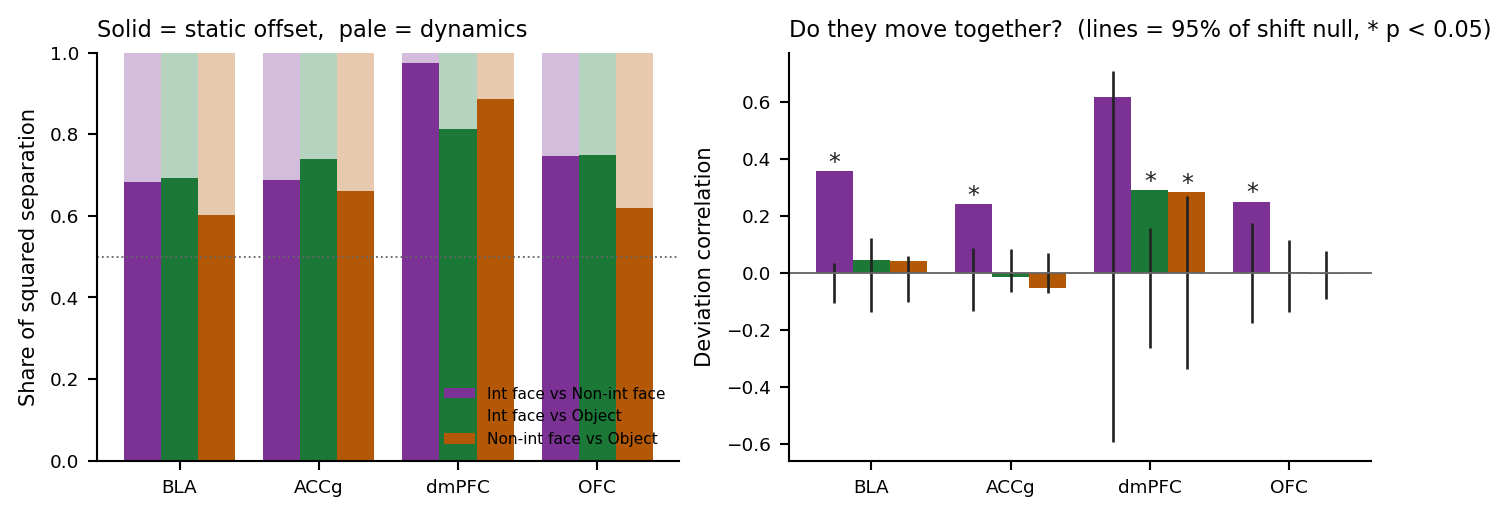

,region,pair_label,offset_share_of_separation,offset_share_corrected,dynamics_share_corrected,deviation_correlation,deviation_correlation_corrected
0,bla,face_interactive__vs__face_non_interactive,0.629,0.683,0.317,0.300,0.356
1,bla,face_interactive__vs__object,0.647,0.692,0.308,0.037,0.044
2,bla,face_non_interactive__vs__object,0.553,0.602,0.398,0.035,0.042
3,accg,face_interactive__vs__face_non_interactive,0.545,0.687,0.313,0.130,0.242
4,accg,face_interactive__vs__object,0.645,0.738,0.262,-0.009,-0.015
5,accg,face_non_interactive__vs__object,0.560,0.661,0.339,-0.033,-0.052
6,dmpfc,face_interactive__vs__face_non_interactive,0.705,0.974,0.026,0.126,0.618
7,dmpfc,face_interactive__vs__object,0.656,0.813,0.187,0.132,0.291
8,dmpfc,face_non_interactive__vs__object,0.652,0.886,0.114,0.064,0.283
9,ofc,face_interactive__vs__face_non_interactive,0.597,0.746,0.254,0.142,0.249


**Circular-shift test for time-locked shared dynamics**

,region,pair_label,observed_deviation_correlation,shift_null_mean,shift_null_sd,z_against_shift_null,p_value
0,bla,face_interactive__vs__face_non_interactive,0.300,-0.040,0.034,10.061,0.012
1,bla,face_interactive__vs__object,0.037,0.003,0.074,0.451,0.463
2,bla,face_non_interactive__vs__object,0.035,0.002,0.030,1.080,0.122
3,accg,face_interactive__vs__face_non_interactive,0.130,-0.024,0.032,4.747,0.012
4,accg,face_interactive__vs__object,-0.009,-0.000,0.027,-0.309,0.561
5,accg,face_non_interactive__vs__object,-0.033,0.007,0.023,-1.708,0.915
6,dmpfc,face_interactive__vs__face_non_interactive,0.126,-0.027,0.076,2.008,0.061
7,dmpfc,face_interactive__vs__object,0.132,-0.023,0.062,2.514,0.012
8,dmpfc,face_non_interactive__vs__object,0.064,-0.009,0.041,1.742,0.024
9,ofc,face_interactive__vs__face_non_interactive,0.142,-0.029,0.056,3.044,0.012


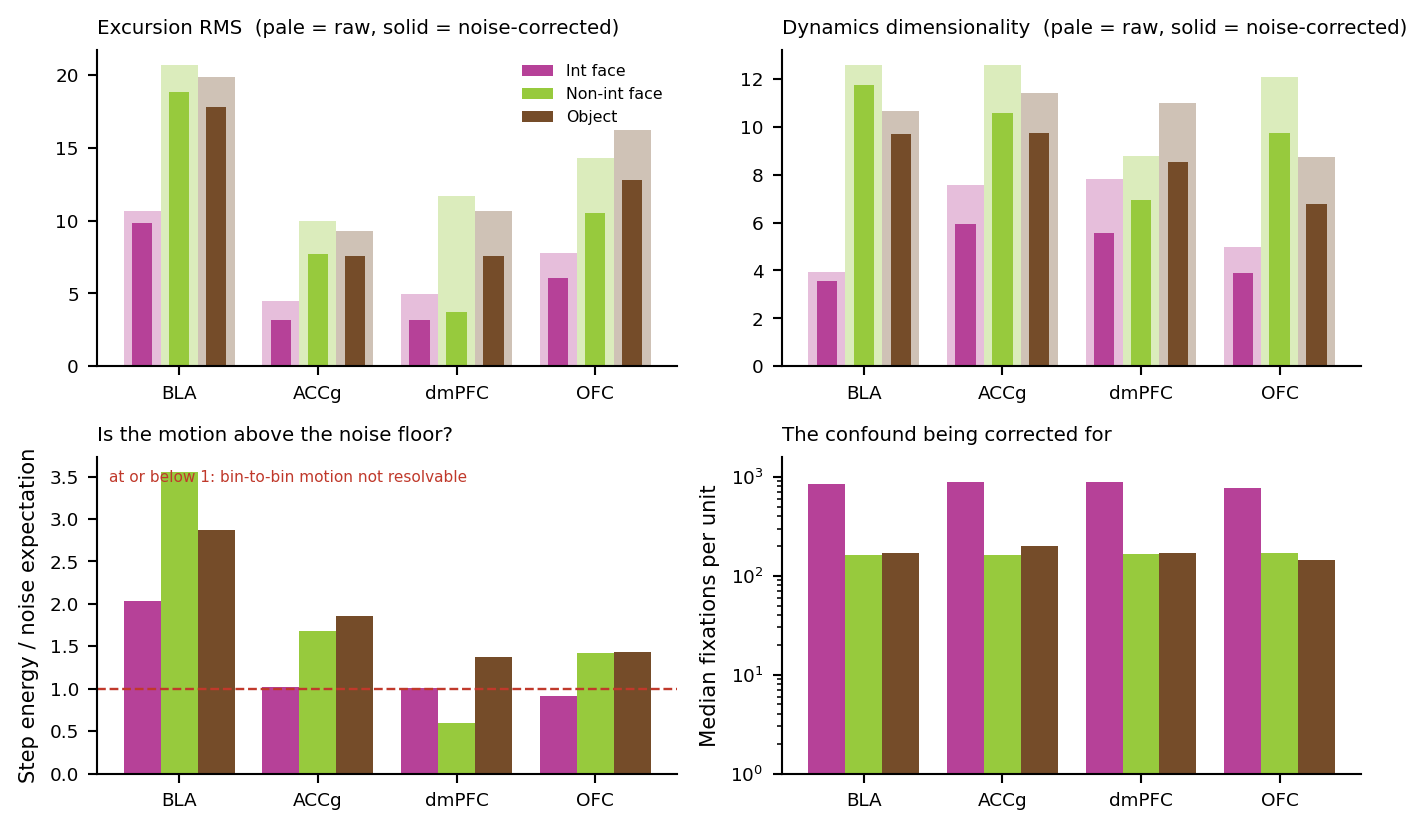

,region,condition,median_n_trials,excursion_rms,excursion_rms_corrected,signal_fraction_of_excursion,speed_over_noise,dynamics_participation_ratio,dynamics_participation_ratio_corrected
0,bla,face_interactive,846.0,10.65,9.87,0.86,2.03,3.93,3.54
1,bla,face_non_interactive,164.0,20.71,18.82,0.83,3.55,12.57,11.76
2,bla,object,168.0,19.90,17.84,0.80,2.87,10.67,9.68
3,accg,face_interactive,883.0,4.51,3.15,0.49,1.02,7.57,5.93
4,accg,face_non_interactive,161.5,9.97,7.68,0.59,1.68,12.59,10.60
5,accg,object,199.0,9.29,7.58,0.67,1.86,11.41,9.75
6,dmpfc,face_interactive,883.0,4.95,3.17,0.41,1.00,7.80,5.58
7,dmpfc,face_non_interactive,167.0,11.72,3.71,0.10,0.60,8.79,6.96
8,dmpfc,object,168.0,10.68,7.58,0.50,1.37,10.98,8.51
9,ofc,face_interactive,768.0,7.81,6.03,0.60,0.91,5.00,3.90


In [13]:
offset_dynamics = save_table(
    pcs.build_offset_vs_dynamics_table(populations, fits, n_components=SHARED_N_COMPONENTS),
    "offset_vs_dynamics",
)
shift_test = save_table(
    pcs.test_deviation_correlation(populations, fits, n_components=SHARED_N_COMPONENTS),
    "deviation_correlation_shift_test",
)
dynamics_summary = save_table(
    pd.concat(
        [
            pcs.condition_dynamics_summary(
                population, fits[region]["concatenated"], n_components=SHARED_N_COMPONENTS
            )
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "condition_dynamics_summary",
)

show(viz.plot_offset_vs_dynamics(offset_dynamics, shift_test=shift_test), "fig13_offset_vs_dynamics")
display(offset_dynamics[[
    "region", "pair_label", "offset_share_of_separation", "offset_share_corrected",
    "dynamics_share_corrected", "deviation_correlation", "deviation_correlation_corrected",
]].round(3))

display(Markdown("**Circular-shift test for time-locked shared dynamics**"))
display(shift_test[[
    "region", "pair_label", "observed_deviation_correlation",
    "shift_null_mean", "shift_null_sd", "z_against_shift_null", "p_value",
]].round(3))

show(viz.plot_condition_dynamics(dynamics_summary), "fig14_condition_dynamics")
display(dynamics_summary[[
    "region", "condition", "median_n_trials", "excursion_rms", "excursion_rms_corrected",
    "signal_fraction_of_excursion", "speed_over_noise",
    "dynamics_participation_ratio", "dynamics_participation_ratio_corrected",
]].round(2))

### 8f. The two dynamics questions, plotted against each other

Horizontal axis: alignment index — *do the conditions vary along the same
directions at all?* Vertical axis: deviation correlation — *do they travel those
directions at the same time?*

These are genuinely independent, and the data separates on one of them and not
the other. Watch which axis orders the pairs. Ringed markers exceed the
circular-shift null at $p < 0.05$.

Note that $z$ and $p$ can disagree at the margin (dmPFC IF/NF has $z = 2.0$ but
$p = 0.061$): the shift null is not Gaussian, and with 81 admissible shifts the
$p$-value is a coarse rank statistic. The $z$-score is the better graded measure;
significance is called on $p$ throughout.

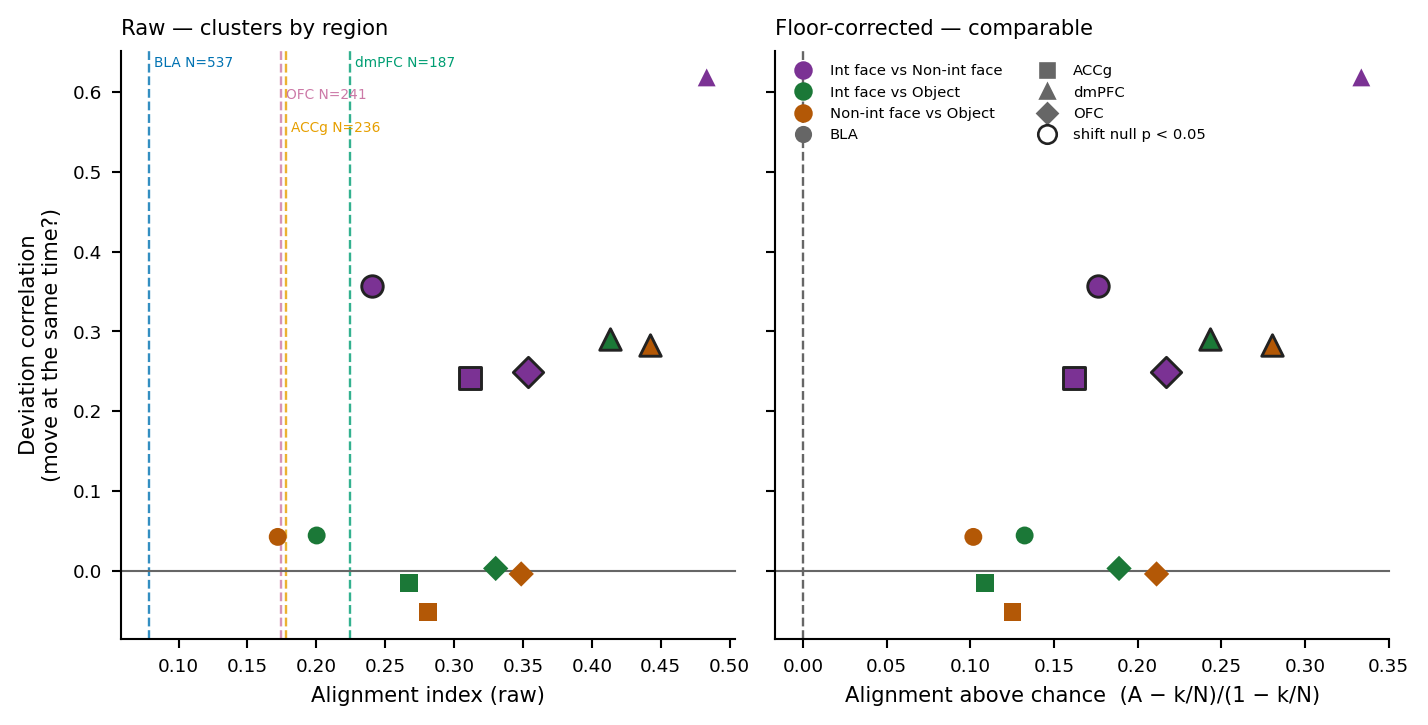

In [14]:
show(
    viz.plot_alignment_vs_comovement(subspace_table, offset_dynamics, shift_test=shift_test),
    "fig15_alignment_vs_comovement",
)

## 9. Is the geometry more than chance, and does it replicate?

**Condition-label shuffle.** Permutes condition labels independently within each
unit, so every neuron keeps all three of its real traces and only the
population's *agreement* about which trace is which is destroyed.

Note which way this null points. It does **not** test whether the conditions are
separated — a shuffled population has three subspaces that are, if anything,
*more* different from each other, because the real conditions share a large common
fixation-locked response. It tests whether the observed **shared** subspace is
real. Both tail probabilities are reported so the direction never has to be
inferred from a sign.

**Unit bootstrap.** Resamples units with replacement and refits. With
trial-averaged input there are no trials left to resample, so this asks "would
another sample of neurons from this region show the same separation" — the
generalisation a population claim needs. It is an interval, not a test.

**Split-half reliability.** Splits units into two disjoint halves and reruns the
pipeline in each. The halves span different unit spaces so their bases are not
comparable, but the *geometry* they imply is.

**What is not available.** There is no unbiased cross-validated distance here.
Cross-validated (crossnobis-style) distances need independent repeats of the same
measurement, and trial averaging removed them. That is why this section reports a
label-shuffle null and resampling intervals rather than a cross-validated effect
size — and why §8e uses a circular-shift null, which needs no repeats.

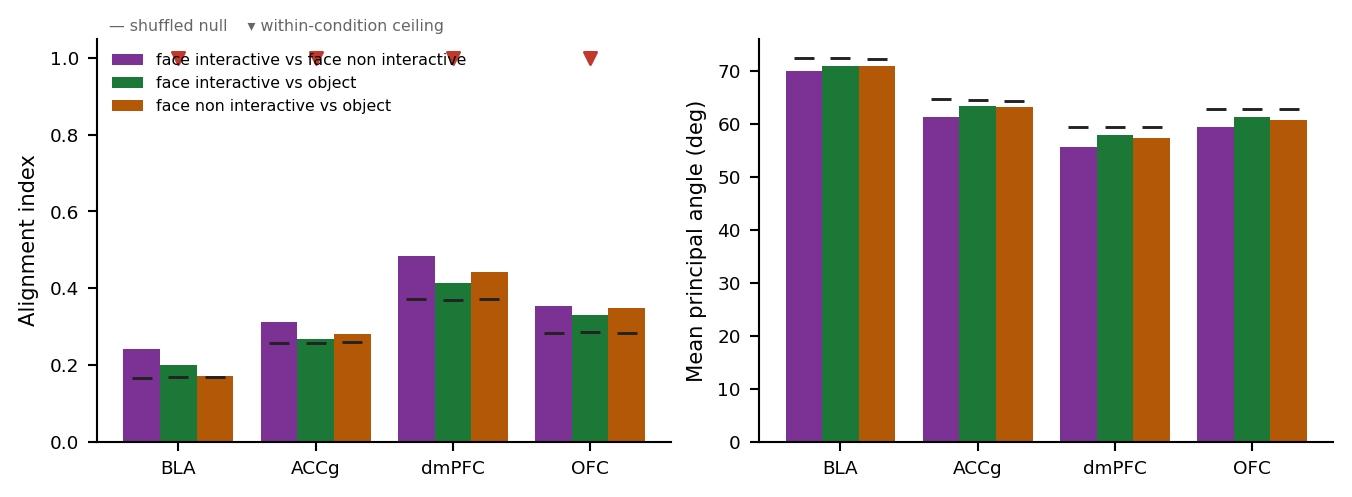

,region,pair_label,observed_alignment_index,shuffled_alignment_index,p_alignment_higher_than_shuffle,observed_mean_principal_angle,shuffled_mean_principal_angle,p_angle_smaller_than_shuffle
0,bla,face_interactive__vs__face_non_interactive,0.241,0.166,0.010,69.858,72.367,0.01
1,bla,face_interactive__vs__object,0.200,0.167,0.010,70.819,72.329,0.01
2,bla,face_non_interactive__vs__object,0.172,0.168,0.376,70.940,72.275,0.01
3,accg,face_interactive__vs__face_non_interactive,0.311,0.256,0.020,61.207,64.557,0.01
4,accg,face_interactive__vs__object,0.267,0.258,0.307,63.384,64.440,0.03
5,accg,face_non_interactive__vs__object,0.281,0.260,0.158,63.103,64.344,0.02
6,dmpfc,face_interactive__vs__face_non_interactive,0.483,0.372,0.010,55.497,59.286,0.01
7,dmpfc,face_interactive__vs__object,0.413,0.369,0.079,57.904,59.352,0.04
8,dmpfc,face_non_interactive__vs__object,0.442,0.372,0.030,57.189,59.350,0.02
9,ofc,face_interactive__vs__face_non_interactive,0.353,0.282,0.010,59.328,62.779,0.01


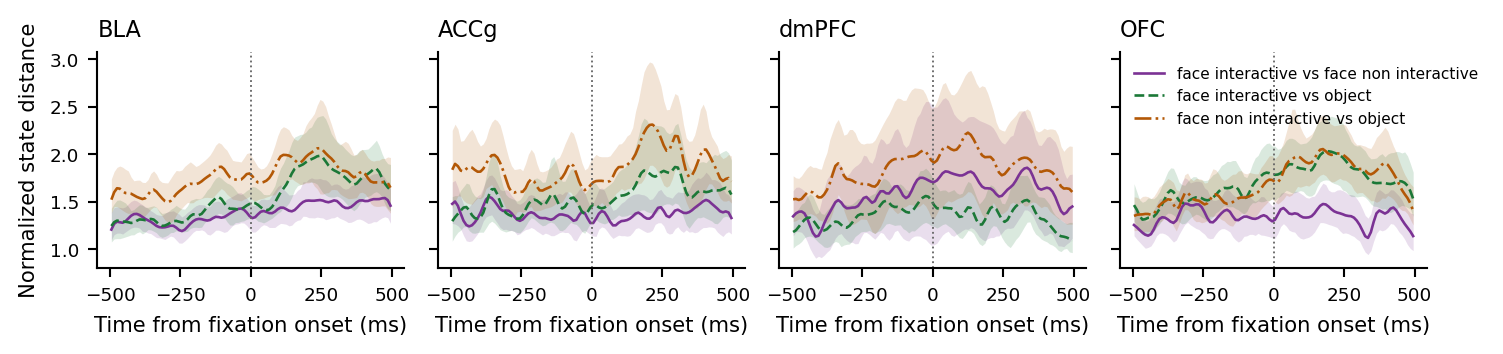

**Split-half reliability of the condition geometry**

,region,n_splits,split_half_distance_correlation,pair_ordering_agreement,closest_pair_agreement,modal_closest_pair,modal_closest_pair_frequency,mean_face_interactive__vs__face_non_interactive,mean_face_interactive__vs__object,mean_face_non_interactive__vs__object
0,accg,50,0.874,0.90,0.90,face_interactive__vs__face_non_interactive,0.95,1.375,1.537,1.841
1,bla,50,0.829,0.92,0.92,face_interactive__vs__face_non_interactive,0.96,1.385,1.542,1.748
2,dmpfc,50,0.480,0.30,0.30,face_interactive__vs__object,0.65,1.558,1.370,1.827
3,ofc,50,0.827,0.10,1.00,face_interactive__vs__face_non_interactive,1.00,1.339,1.685,1.678


In [15]:
null_comparison = save_table(
    pd.concat(
        [
            pcs.build_pairwise_null_comparison(
                population, n_components=SHARED_N_COMPONENTS,
                n_shuffles=N_LABEL_SHUFFLES, seed=RANDOM_SEED,
            )
            for population in populations.values()
        ],
        ignore_index=True,
    ),
    "condition_shuffle_null",
)
show(viz.plot_null_comparison(null_comparison, ceiling=alignment_ceiling), "fig16_shuffle_null")
display(null_comparison[[
    "region", "pair_label",
    "observed_alignment_index", "shuffled_alignment_index", "p_alignment_higher_than_shuffle",
    "observed_mean_principal_angle", "shuffled_mean_principal_angle", "p_angle_smaller_than_shuffle",
]].round(3))

separation = save_table(
    pd.concat(
        [
            pcs.time_resolved_separation(
                population, fits[region]["concatenated"],
                n_components=SHARED_N_COMPONENTS, n_bootstrap=N_UNIT_BOOTSTRAPS, seed=RANDOM_SEED,
            )
            for region, population in populations.items()
        ],
        ignore_index=True,
    ),
    "time_resolved_separation",
)
show(viz.plot_time_resolved_separation(separation), "fig17_time_resolved_separation")

reliability_summary = save_table(
    pcs.summarize_split_half_reliability(
        pd.concat(
            [
                pcs.split_half_geometry_reliability(
                    population, n_components=SHARED_N_COMPONENTS,
                    n_splits=N_SPLIT_HALVES, seed=RANDOM_SEED,
                )
                for population in populations.values()
            ],
            ignore_index=True,
        )
    ),
    "split_half_reliability",
)
display(Markdown("**Split-half reliability of the condition geometry**"))
display(reliability_summary.round(3))

## 10. What can be claimed

The cell below reads the saved tables and states each claim with its supporting
numbers, so it stays correct when the analysis is rerun. The narrative that
follows interprets it.

In [16]:
lines: list[str] = []
regions = sorted(populations)

lines.append("### Dimensionality\n")
lines.append(
    f"- **k = {SHARED_N_COMPONENTS}** PCs reach {VARIANCE_THRESHOLD:.0%} of the concatenated variance in "
    "every region ("
    + ", ".join(f"{style.region_label(r)} {per_region_components[r]}" for r in regions)
    + f"); {style.region_label(binding)} is binding."
)
pr = dimensionality[dimensionality["fit_scope"] == "concatenated"].set_index("region")["participation_ratio"]
lines.append(
    "- But the participation ratio is only "
    + ", ".join(f"{style.region_label(r)} {pr[r]:.1f}" for r in regions)
    + " — most of the action is in a handful of dimensions; the other ~35 carry the 5% tail."
)

lines.append("\n### Where the variance lives\n")
for region in regions:
    row = shares.loc[region]
    lines.append(
        f"- **{style.region_label(region)}**: shared time course {row['condition_independent_time']:.0%}, "
        f"condition offset {row['condition_main_effect']:.0%}, "
        f"condition x time {row['condition_by_time_interaction']:.0%}."
    )
lines.append(
    "- Across regions the **static offset is the single largest term**, so the visual separation "
    "in fig04 is mostly positional."
)

lines.append("\n### Subspace overlap (floor-corrected, cross-region comparable)\n")
ranks = []
for region in regions:
    sub = pair_summary[pair_summary["region"] == region].set_index("pair")
    ordered = sub["alignment_above_floor"].sort_values(ascending=False)
    ranks.append(str(ordered.index[0]))
    lines.append(
        f"- **{style.region_label(region)}**: "
        + ", ".join(f"{p} {sub.loc[p, 'alignment_above_floor']:.3f}" for p in ["IF/NF", "IF/OB", "NF/OB"] if p in sub.index)
        + f"  (raw floor k/N = {sub['alignment_floor'].iloc[0]:.3f})"
    )
lines.append(
    f"- **IF/NF is the most-aligned pair in {ranks.count('IF/NF')} of {len(regions)} regions.** "
    "The two face conditions share more subspace structure than either shares with object — "
    "but the margins are modest."
)

lines.append("\n### Time-locked shared dynamics — the clearest dissociation\n")
for region in regions:
    sub = shift_test[shift_test["region"] == region].set_index("pair_label")
    parts = []
    for label, short in PAIR_SHORT.items():
        if label not in sub.index:
            continue
        z = float(sub.loc[label, "z_against_shift_null"])
        significant = float(sub.loc[label, "p_value"]) < 0.05
        parts.append(f"{short} z={z:+.1f}{'*' if significant else ''}")
    lines.append(f"- **{style.region_label(region)}**: " + ", ".join(parts))
significant = shift_test[shift_test["p_value"] < 0.05]
face_face = significant[significant["pair_label"] == "face_interactive__vs__face_non_interactive"]
lines.append(
    f"- IF/NF exceeds the shift null in **{len(face_face)} of {len(regions)}** regions; "
    f"face-vs-object pairs do so in "
    f"**{len(significant) - len(face_face)} of {2 * len(regions)}** cases."
)

lines.append("\n### Dynamic amplitude, after correcting for the 5:1 trial imbalance\n")
for region in regions:
    sub = dynamics_summary[dynamics_summary["region"] == region].set_index("condition")
    lines.append(
        f"- **{style.region_label(region)}** excursion (corrected): "
        + ", ".join(f"{SHORT[c]} {sub.loc[c, 'excursion_rms_corrected']:.1f}" for c in SHORT if c in sub.index)
        + "  |  dynamics dimensionality: "
        + ", ".join(f"{SHORT[c]} {sub.loc[c, 'dynamics_participation_ratio_corrected']:.1f}" for c in SHORT if c in sub.index)
    )
resolvable = dynamics_summary[dynamics_summary["speed_over_noise"] > 1.0] if "speed_over_noise" in dynamics_summary else dynamics_summary.iloc[:0]
lines.append(
    f"- Bin-to-bin speed is resolvable above the noise floor in only "
    f"{len(resolvable)} of {len(dynamics_summary)} region x condition cases — do not quote speed."
)

display(Markdown("\n".join(lines)))
save_table(pd.DataFrame({"claim": lines}), "claims")

### Dimensionality

- **k = 42** PCs reach 95% of the concatenated variance in every region (ACCg 40, BLA 42, dmPFC 33, OFC 38); BLA is binding.
- But the participation ratio is only ACCg 7.4, BLA 7.8, dmPFC 5.4, OFC 7.1 — most of the action is in a handful of dimensions; the other ~35 carry the 5% tail.

### Where the variance lives

- **ACCg**: shared time course 18%, condition offset 46%, condition x time 36%.
- **BLA**: shared time course 21%, condition offset 45%, condition x time 33%.
- **dmPFC**: shared time course 18%, condition offset 54%, condition x time 28%.
- **OFC**: shared time course 19%, condition offset 45%, condition x time 35%.
- Across regions the **static offset is the single largest term**, so the visual separation in fig04 is mostly positional.

### Subspace overlap (floor-corrected, cross-region comparable)

- **ACCg**: IF/NF 0.196, IF/OB 0.129, NF/OB 0.119  (raw floor k/N = 0.178)
- **BLA**: IF/NF 0.196, IF/OB 0.151, NF/OB 0.109  (raw floor k/N = 0.078)
- **dmPFC**: IF/NF 0.326, IF/OB 0.230, NF/OB 0.261  (raw floor k/N = 0.225)
- **OFC**: IF/NF 0.239, IF/OB 0.188, NF/OB 0.189  (raw floor k/N = 0.174)
- **IF/NF is the most-aligned pair in 4 of 4 regions.** The two face conditions share more subspace structure than either shares with object — but the margins are modest.

### Time-locked shared dynamics — the clearest dissociation

- **ACCg**: IF/NF z=+4.7*, IF/OB z=-0.3, NF/OB z=-1.7
- **BLA**: IF/NF z=+10.1*, IF/OB z=+0.5, NF/OB z=+1.1
- **dmPFC**: IF/NF z=+2.0, IF/OB z=+2.5*, NF/OB z=+1.7*
- **OFC**: IF/NF z=+3.0*, IF/OB z=-0.1, NF/OB z=-0.2
- IF/NF exceeds the shift null in **3 of 4** regions; face-vs-object pairs do so in **2 of 8** cases.

### Dynamic amplitude, after correcting for the 5:1 trial imbalance

- **ACCg** excursion (corrected): IF 3.1, NF 7.7, OB 7.6  |  dynamics dimensionality: IF 5.9, NF 10.6, OB 9.8
- **BLA** excursion (corrected): IF 9.9, NF 18.8, OB 17.8  |  dynamics dimensionality: IF 3.5, NF 11.8, OB 9.7
- **dmPFC** excursion (corrected): IF 3.2, NF 3.7, OB 7.6  |  dynamics dimensionality: IF 5.6, NF 7.0, OB 8.5
- **OFC** excursion (corrected): IF 6.0, NF 10.5, OB 12.8  |  dynamics dimensionality: IF 3.9, NF 9.7, OB 6.8
- Bin-to-bin speed is resolvable above the noise floor in only 10 of 12 region x condition cases — do not quote speed.

,claim
0,### Dimensionality\n
1,- **k = 42** PCs reach 95% of the concatenated...
2,- But the participation ratio is only ACCg 7.4...
3,\n### Where the variance lives\n
4,"- **ACCg**: shared time course 18%, condition ..."
5,"- **BLA**: shared time course 21%, condition o..."
6,"- **dmPFC**: shared time course 18%, condition..."
7,"- **OFC**: shared time course 19%, condition o..."
8,- Across regions the **static offset is the si...
9,"\n### Subspace overlap (floor-corrected, cross..."


### Reading it together

Three statements the analysis supports, in decreasing order of confidence.

**1. The three conditions occupy clearly distinct population states, and the
distinction is mostly positional.** The offset term is the largest single
component of the variance in every region, and 55–75% of the squared separation
between any pair is static. The clean clustering in fig04 is real, but it is a
statement about *where* the population sits during each kind of fixation, not
about different trajectories through state space.

**2. Interactive and non-interactive face share a time-locked dynamic that
neither shares with object.** This is the sharpest result and it does not follow
from the subspace measures. Floor-corrected alignment ranks IF/NF highest in every
region, but only narrowly. The deviation correlation separates the pairs
decisively: IF/NF is well above its circular-shift null in BLA, ACCg and OFC,
while both face-vs-object pairs sit at zero in those regions. The two face
conditions do not merely have access to similar directions — they move along them
*at the same moments*, which object fixations do not.

Note this could not have been seen from the alignment index alone: fig15 shows the
pairs are not ordered by the horizontal axis at all.

**3. The interactive-face state is more compact and lower-dimensional.** After
noise correction its excursion is roughly half that of the other conditions in
every region, and its dynamics participation ratio is consistently lower. This
survives the 5:1 trial-count correction, which is the obvious artefactual
explanation and the one to rule out first.

**dmPFC is the exception throughout.** It has the highest floor-corrected
alignment for every pair, and it is the one region where face-vs-object deviation
correlations are also above the shift null. Its conditions share more structure
overall and are separated less sharply — a different regime, not a weaker version
of the same one.

### What is *not* supported

- **Any claim about rotational dynamics, speed differences, or trajectory
  shape at fine timescales.** `speed_over_noise` is near 1 in most region ×
  condition cases: bin-to-bin motion is not resolvable above the noise the
  20 ms smoothing leaves behind.
- **Cross-region comparison of raw alignment indices or principal angles.**
  The chance floor is $k/N$ and $N$ ranges from 187 to 537. Use
  `alignment_above_floor`.
- **Anything requiring a cross-validated effect size.** Trial averaging removed
  the repeats. The nulls here are permutation-based and the intervals are
  resampling-based; neither is a cross-validated distance.
- **A causal or directional reading of the asymmetry** in
  `variance_explained_fraction`. That a condition's PCs capture more of another
  than the reverse reflects how broadly its variance is spread, nothing more.

In [17]:
display(Markdown("**Saved outputs**"))
display(Markdown("\n".join(f"- `{name}`" for name in sorted(FIGURE_MANIFEST))))
print(FIGURE_DIR)

**Saved outputs**

- `claims.csv`
- `condition_dynamics_summary.csv`
- `condition_identity_confusion.csv`
- `condition_shuffle_null.csv`
- `cross_condition_variance_curves.csv`
- `deviation_correlation_shift_test.csv`
- `dimensionality_by_region.csv`
- `fig00_unit_inventory.pdf`
- `fig00_unit_inventory.png`
- `fig01_identity_checks.pdf`
- `fig01_identity_checks.png`
- `fig02_cumulative_variance.pdf`
- `fig02_cumulative_variance.png`
- `fig03_variance_spectra.pdf`
- `fig03_variance_spectra.png`
- `fig04_pc_trajectories_3d.pdf`
- `fig04_pc_trajectories_3d.png`
- `fig05_pc_planes.pdf`
- `fig05_pc_planes.png`
- `fig06_pc_timecourses.pdf`
- `fig06_pc_timecourses.png`
- `fig07_variance_decomposition.pdf`
- `fig07_variance_decomposition.png`
- `fig08_condition_dynamics_only_3d.pdf`
- `fig08_condition_dynamics_only_3d.png`
- `fig09_cross_condition_variance_curves.pdf`
- `fig09_cross_condition_variance_curves.png`
- `fig10_alignment_matrix.pdf`
- `fig10_alignment_matrix.png`
- `fig11_principal_angle_spectra.pdf`
- `fig11_principal_angle_spectra.png`
- `fig12_subspace_distance_map.pdf`
- `fig12_subspace_distance_map.png`
- `fig13_offset_vs_dynamics.pdf`
- `fig13_offset_vs_dynamics.png`
- `fig14_condition_dynamics.pdf`
- `fig14_condition_dynamics.png`
- `fig15_alignment_vs_comovement.pdf`
- `fig15_alignment_vs_comovement.png`
- `fig16_shuffle_null.pdf`
- `fig16_shuffle_null.png`
- `fig17_time_resolved_separation.pdf`
- `fig17_time_resolved_separation.png`
- `offset_vs_dynamics.csv`
- `pairwise_subspace_metrics.csv`
- `pairwise_subspace_summary.csv`
- `pca_identity_checks.csv`
- `split_half_reliability.csv`
- `stored_pca_comparison.csv`
- `subspace_offset_invariance.csv`
- `time_resolved_separation.csv`
- `unit_inventory.csv`
- `variance_decomposition.csv`
- `within_condition_alignment_ceiling.csv`

/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_population_pc_subspace/all_units
